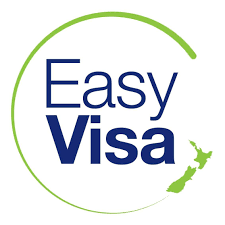

# **EasyVisa**

## **Context**

Business communities in the United States are facing high demand for human resources, but one of the constant challenges is identifying and attracting the right talent, which is perhaps the most important element in remaining competitive. Companies in the United States look for hard-working, talented, and qualified individuals both locally as well as abroad.

The Immigration and Nationality Act (INA) of the US permits foreign workers to come to the United States to work on either a temporary or permanent basis. The act also protects US workers against adverse impacts on their wages or working conditions by ensuring US employers' compliance with statutory requirements when they hire foreign workers to fill workforce shortages. The immigration programs are administered by the Office of Foreign Labor Certification (OFLC).

OFLC processes job certification applications for employers seeking to bring foreign workers into the United States and grants certifications in those cases where employers can demonstrate that there are not sufficient US workers available to perform the work at wages that meet or exceed the wage paid for the occupation in the area of intended employment.



## **Objective**

In FY 2016, the OFLC processed 775,979 employer applications for 1,699,957 positions for temporary and permanent labor certifications. This was a nine percent increase in the overall number of processed applications from the previous year. The process of reviewing every case is becoming a tedious task as the number of applicants is increasing every year.

The increasing number of applicants every year calls for a Machine Learning based solution that can help in shortlisting the candidates having a higher chance of VISA approval. OFLC has hired the firm EasyVisa for data-driven solutions. You, as a data scientist at EasyVisa, have to analyze the data provided and, with the help of a classification model:

Facilitate the process of visa approvals.
Recommend a suitable profile for the applicants for whom the visa should be certified or denied based on the drivers that significantly influence the case status.

## **Data Description**

The data contains the different attributes of the employee and the employer. The detailed data dictionary is given below.

case_id: ID of each visa application

continent: Information of continent the employee

education_of_employee: Information of education of the employee

has_job_experience: Does the employee have any job experience? Y= Yes; N = No
requires_job_training: Does the employee require any job training? Y = Yes; N = No

no_of_employees: Number of employees in the employer's company

yr_of_estab: Year in which the employer's company was established

region_of_employment: Information of foreign worker's intended region of employment in the US.

prevailing_wage: Average wage paid to similarly employed workers in a specific occupation in the area of intended employment. The purpose of the prevailing wage is to ensure that the foreign worker is not underpaid compared to other workers offering the same or similar service in the same area of employment.

unit_of_wage: Unit of prevailing wage. Values include Hourly, Weekly, Monthly, and Yearly.

full_time_position: Is the position of work full-time? Y = Full-Time Position; N = Part-Time Position

case_status: Flag indicating if the Visa was certified or denied

## **Importing the required packages**


In [ ]:
#libraries to read and manipulate data
import numpy as np
import pandas as pd

#libraries to visualize data
import matplotlib.pyplot as plt
import seaborn as sns

#libraries for model building and tuning
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (BaggingClassifier,RandomForestClassifier,
                              GradientBoostingClassifier, AdaBoostClassifier, StackingClassifier)
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

#libraries for metrics and statistics
from sklearn import metrics
import scipy.stats as stats
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score, roc_auc_score


# To undersample and oversample the data
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

import warnings
warnings.filterwarnings('ignore')

## **Loading the daaset**

In [ ]:
data = pd.read_csv('/content/sample_data/EasyVisa.csv')

## copying the dataset to another variable
df = data.copy()

## **Data Overview**

### View the first and last 5 rows of the dataset

In [ ]:
df.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


In [ ]:
df.tail()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.57,Year,Y,Certified
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.79,Year,Y,Certified
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.85,Year,N,Certified
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.77,Year,Y,Certified
25479,EZYV25480,Asia,Bachelor's,Y,N,3195,1960,Midwest,70876.91,Year,Y,Certified


### Understand the shape of the dataset


In [ ]:
df.shape

(25480, 12)

**Observation:**

* There are 25480 observations and 12 columns in the dataset

### Checking the data types of the columns for the dataset

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  object 
 1   continent              25480 non-null  object 
 2   education_of_employee  25480 non-null  object 
 3   has_job_experience     25480 non-null  object 
 4   requires_job_training  25480 non-null  object 
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  object 
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  object 
 10  full_time_position     25480 non-null  object 
 11  case_status            25480 non-null  object 
dtypes: float64(1), int64(2), object(9)
memory usage: 2.3+ MB


**Observations:**

* There are 12 columns
    * 2 of these columns are integer datatypes.
    * 9 of them being objects.
    * Only 1 of them being a float.
* There seems to be no missing values for any of these columns.

* We should convert the object type columns to categories, which reduces the memory required to store the dataframe.

* We need to drop case_id column from the dataset.


In [ ]:
# convert all columns with dtype object into category
for col in df.columns[df.dtypes=='object']:
    df[col] = df[col].astype('category')

In [ ]:
# drop the column *case_id* from the dataframe
df.drop(labels='case_id', axis=1, inplace=True)

In [ ]:
# confirm conversions and dropped variable
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   continent              25480 non-null  category
 1   education_of_employee  25480 non-null  category
 2   has_job_experience     25480 non-null  category
 3   requires_job_training  25480 non-null  category
 4   no_of_employees        25480 non-null  int64   
 5   yr_of_estab            25480 non-null  int64   
 6   region_of_employment   25480 non-null  category
 7   prevailing_wage        25480 non-null  float64 
 8   unit_of_wage           25480 non-null  category
 9   full_time_position     25480 non-null  category
 10  case_status            25480 non-null  category
dtypes: category(8), float64(1), int64(2)
memory usage: 797.7 KB


**Observations:**

* The memory required to store the dataframe before was ~ 2.3 MB after conversion it is now ~800kB.

### Viewing the values in category data types

In [ ]:
# view what are the values in object data types
cat_columns = ['continent', 'education_of_employee', 'has_job_experience', 'requires_job_training', 'region_of_employment','full_time_position', 'unit_of_wage', 'case_status']
for i in cat_columns:
    print(df[i].value_counts())
    print("*" * 50)

continent
Asia             16861
Europe            3732
North America     3292
South America      852
Africa             551
Oceania            192
Name: count, dtype: int64
**************************************************
education_of_employee
Bachelor's     10234
Master's        9634
High School     3420
Doctorate       2192
Name: count, dtype: int64
**************************************************
has_job_experience
Y    14802
N    10678
Name: count, dtype: int64
**************************************************
requires_job_training
N    22525
Y     2955
Name: count, dtype: int64
**************************************************
region_of_employment
Northeast    7195
South        7017
West         6586
Midwest      4307
Island        375
Name: count, dtype: int64
**************************************************
full_time_position
Y    22773
N     2707
Name: count, dtype: int64
**************************************************
unit_of_wage
Year     22962
Hour      2157
Week

**Observations:**

* Now there are 8 categorical column among which

    * The continent column have total 6 unique values  ['Africa', 'Asia', 'Europe', 'North America', 'Oceania', 'South America'].
    * The education_of_employee column has total 4 unique values ['Bachelor's', 'Doctorate', 'High School', 'Master's'].
    * The has_job_experience column has total 2 unique values ['N', 'Y'].
    * The requires_job_training column has total 2 unique values ['N', 'Y'].
    * The region_of_employment coulmn has total 5 unique values ['Island', 'Midwest', 'Northeast', 'South', 'West'].
    * The full_time_position column has total 2 unique values ['N', 'Y'].
    * The unit_of_wage coulmn has total 4 unique values ['Hour', 'Month', 'Week', 'Year'].
    * The case_status coulmn has total 2 unique values ['Certified', 'Denied'].

### Getting the statistical summary for the dataset

In [ ]:
df.describe(include='all').T
# setting include='all' will get the statistical summary for both the numerical and categorical variables.

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
continent,25480,6,Asia,16861,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education_of_employee,25480,4,Bachelor's,10234,NaN,NaN,NaN,NaN,NaN,NaN,NaN
has_job_experience,25480,2,Y,14802,NaN,NaN,NaN,NaN,NaN,NaN,NaN
requires_job_training,25480,2,N,22525,NaN,NaN,NaN,NaN,NaN,NaN,NaN
no_of_employees,25480.0,NaN,NaN,NaN,5667.04321,22877.928848,-26.0,1022.0,2109.0,3504.0,602069.0
yr_of_estab,25480.0,NaN,NaN,NaN,1979.409929,42.366929,1800.0,1976.0,1997.0,2005.0,2016.0
region_of_employment,25480,5,Northeast,7195,NaN,NaN,NaN,NaN,NaN,NaN,NaN
prevailing_wage,25480.0,NaN,NaN,NaN,74455.814592,52815.942327,2.1367,34015.48,70308.21,107735.5125,319210.27
unit_of_wage,25480,4,Year,22962,NaN,NaN,NaN,NaN,NaN,NaN,NaN
full_time_position,25480,2,Y,22773,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Observations:**

* The min value for no_of_employees cant be -26

* Most employees have a bachelor's degree

* Most of the employment is from Northeast region.

* Most popular continent which applicants are from is Asia.

* Average prevailing wage is $74456.There's also a very huge difference in 75th percentile and maximum value

* There's an extremely large gap between the 75th percentile and the max value of no_of_employees

* Most of the employees have job experience.

* Most of the employees are certified employees.

In [ ]:
# checking the number of negative value rows in no_of_employees column
df.loc[data['no_of_employees'] < 0].shape

(33, 11)

**Observations:**

* There are total 13 rows of no_of_employees have negative values.
* Change the negative to positive value assuming there are entry errors.

In [ ]:
#to change the negative to positive assuming there are entry errors
data["no_of_employees"] = abs(data["no_of_employees"])

### Checking for duplicate values

In [ ]:
df.duplicated().sum()

np.int64(0)

**Observations:**

* There are no duplicate values in the data

### Checking for null values in the data

In [ ]:
df.isnull().sum()

,0
continent,0
education_of_employee,0
has_job_experience,0
requires_job_training,0
no_of_employees,0
yr_of_estab,0
region_of_employment,0
prevailing_wage,0
unit_of_wage,0
full_time_position,0


**Observation:**

* We don't have missing values in the data.

## **Exploratory Data Analysis**

In [ ]:
# function to plot a boxplot and a histogram along the same scale.


def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to the show density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a star will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette="winter"
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="orange", linestyle="-"
    )  # Add median to the histogram

In [ ]:
def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 2, 6))
    else:
        plt.figure(figsize=(n + 2, 6))

    plt.xticks(rotation=45, fontsize=10)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n],
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

### **Univariate Analysis**

#### **Observation on continent**

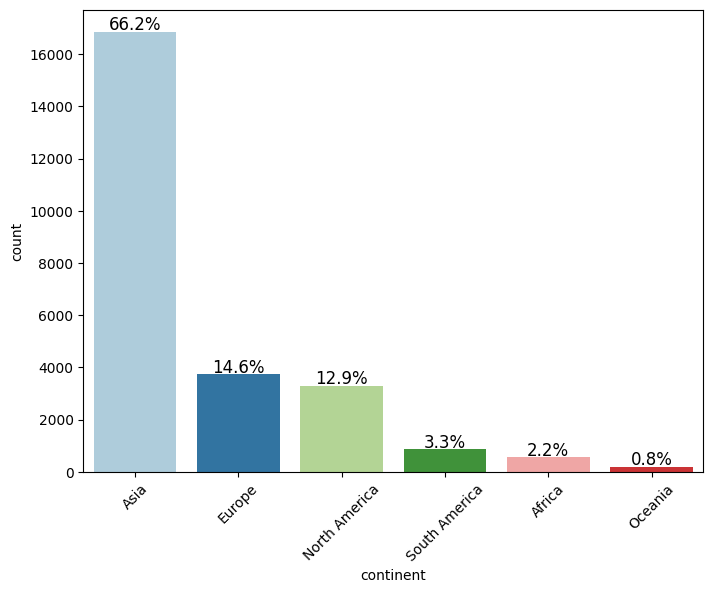

In [ ]:
labeled_barplot(data=df, feature='continent', perc=True)


**Observations:**

* Europe and North America have the close numbers of applicants 14.6% and 12.9% respectively.
* The moost of the visa applicants are from Asia 66%, which makes it the highest population of the continent.
* The less number of the visa applicants are from Oceania 0.8%, which makes it the lowestest population of the continent.


#### **Observation on Education Level**

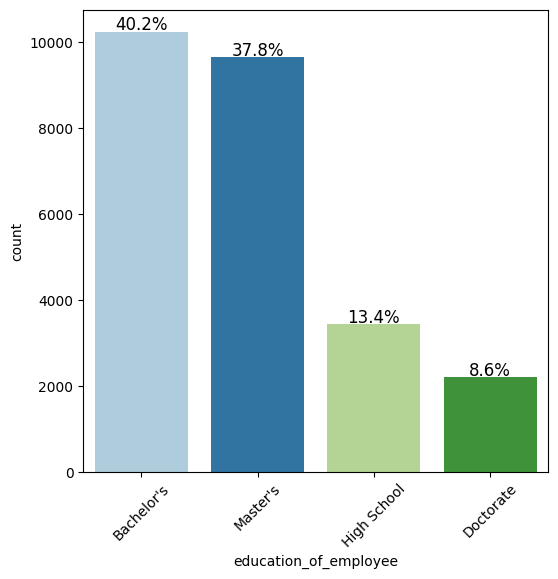

In [ ]:
labeled_barplot(data=df, feature='education_of_employee', perc=True)

**Observations:**

* Most of the applicants have either bachelor's degree(40.2%) or Master's degree(37.8%).
* Only 8.6% of the applicants have the doctorate degree.
* 13.4% of the applicants have completed till high school.


#### **Observation on Job Experience**

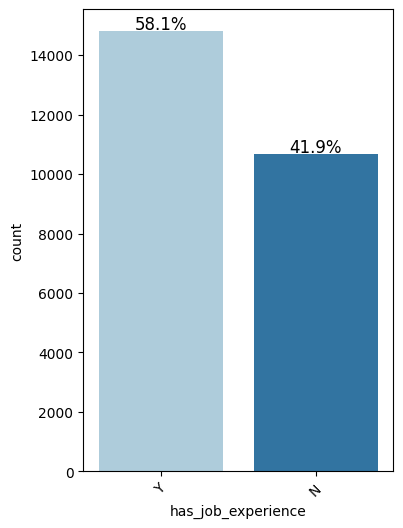

In [ ]:
labeled_barplot(data=df, feature='has_job_experience', perc=True)

**Observations:**

* Almost 58% of the applicants have no job.

#### **Observation on Job Requirement**

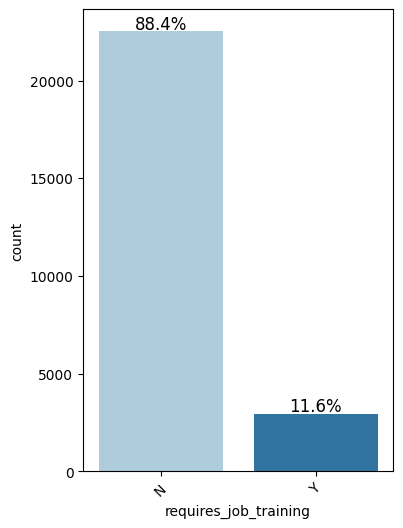

In [ ]:
labeled_barplot(data=df, feature='requires_job_training', perc=True)

**Observations:**

* Most of the jobs don't require any training for the applicants.

#### **Observation on Employement Region**

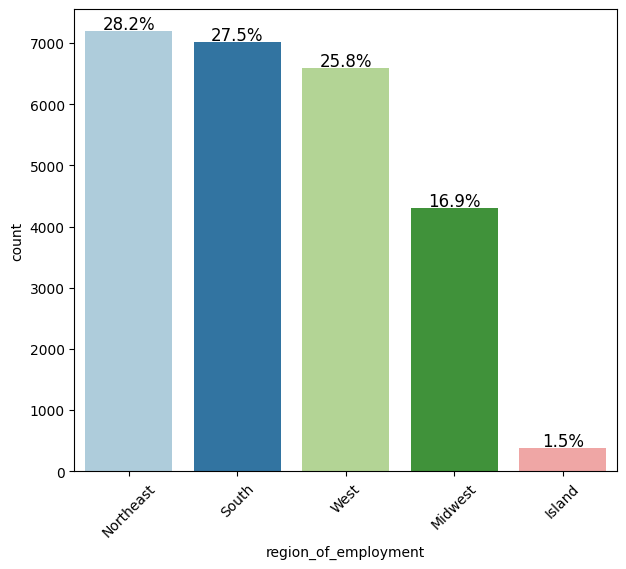

In [ ]:
labeled_barplot(data=df, feature='region_of_employment', perc=True)

**Observations:**

* The island region has the lowest number of work visa applicants which is 1.5%.
* Majority of the appplicants are from Northeast, south and West regions of the United States.

**Observations on Position Type**

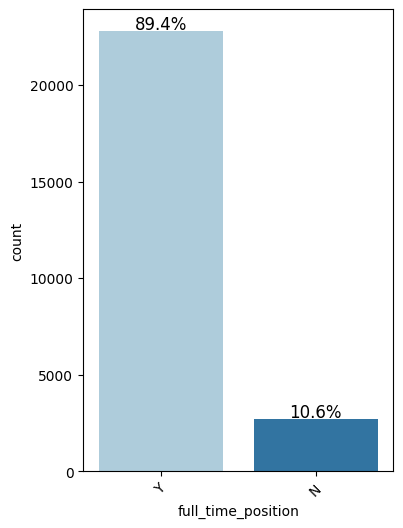

In [ ]:
labeled_barplot(data=df, feature='full_time_position', perc=True)

**Observations:**

* 89.4% of the applicants are for full-time employement.

#### **Observation on Wage Unit**

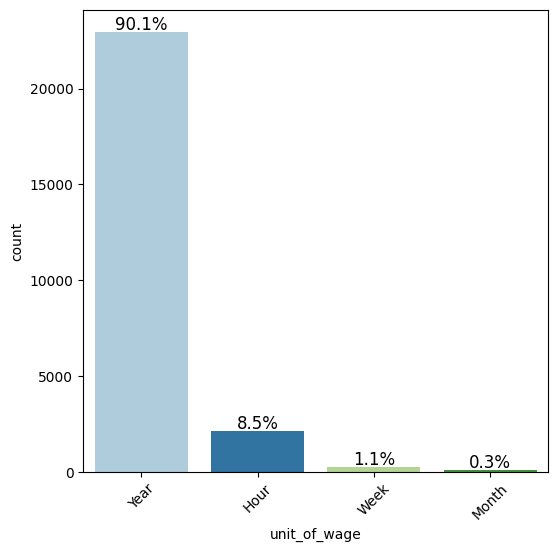

In [ ]:
labeled_barplot(data=df, feature='unit_of_wage', perc=True)

**Observations:**

* The majority of the employees recive the wages yearly.

#### **Observation on Case ID**

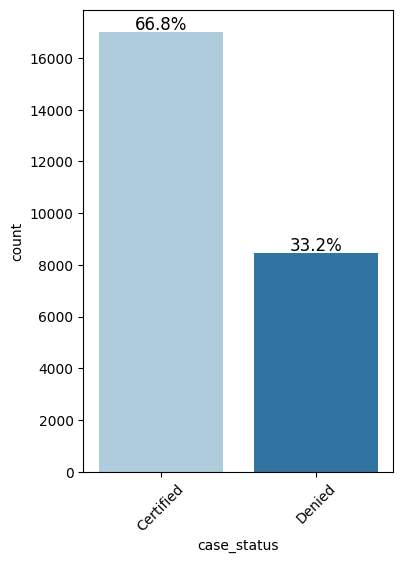

In [ ]:
labeled_barplot(data=df, feature='case_status', perc=True)

**Observations:**

* 66.8% of the visa applicants are certified while 33.2% are denied.

#### **Observation on Number Of Employees**

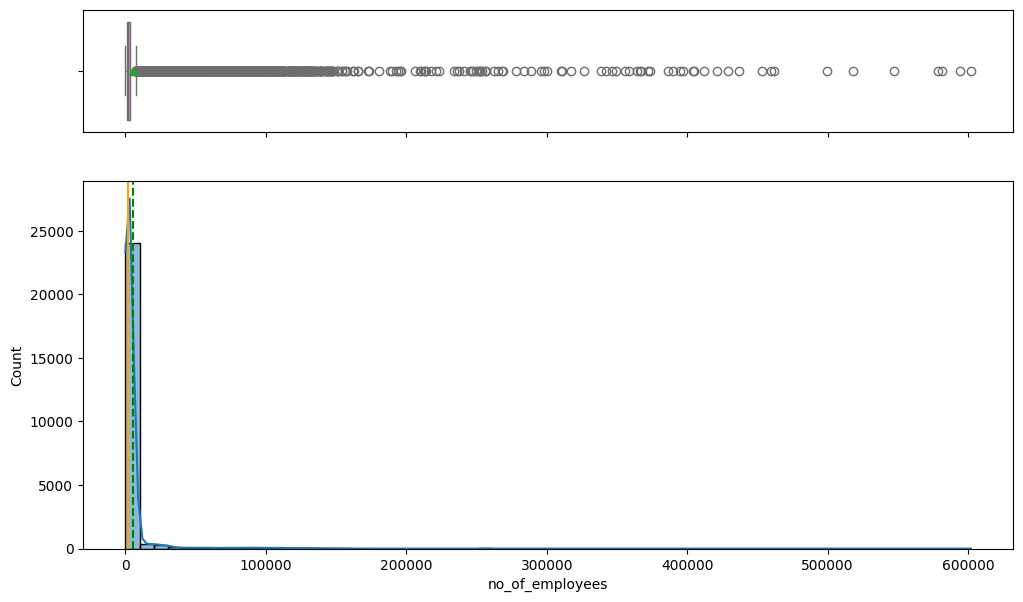

In [ ]:
histogram_boxplot(data=df, feature='no_of_employees', kde = True, bins = 60)

**Observations**

* We can see the outliers in the dataset.
* Right skewed distribution.

### **Bivariant Analysis**

In [ ]:
def plot_stacked_bar_chart(data, predictor_column, target_column):
    """
    Generate a stacked bar chart based on two specified columns from a DataFrame.

    data: DataFrame
    predictor_column: Column name of the predictor variable
    target_column: Column name of the target variable
    """
    count = data[predictor_column].nunique()
    sorter = data[target_column].value_counts().index[-1]

    category_count = pd.crosstab(data[predictor_column], data[target_column], normalize='index').sort_values(
       by=sorter, ascending=False
    )
    print(category_count)
    # Plot a stacked bar chart
    category_count.plot(kind='bar', stacked=True, figsize=(10, 6))

    # Add labels and title
    plt.xlabel(predictor_column)
    plt.ylabel('Count')
    plt.title(f'Stacked Bar Chart of {target_column} by {predictor_column}')

    # Show the plot
    plt.show()

#### **Observation on Correlation Matrix on Numerical Variables**

In [ ]:
# Select only the numerical columns
numerical_columns = data.select_dtypes(include=['int64', 'float64'])

# Find the correlation between the numerical columns
correlation_matrix = numerical_columns.corr()

# Print the correlation matrix
print(correlation_matrix)

                 no_of_employees  yr_of_estab  prevailing_wage
no_of_employees         1.000000    -0.017770        -0.009523
yr_of_estab            -0.017770     1.000000         0.012342
prevailing_wage        -0.009523     0.012342         1.000000


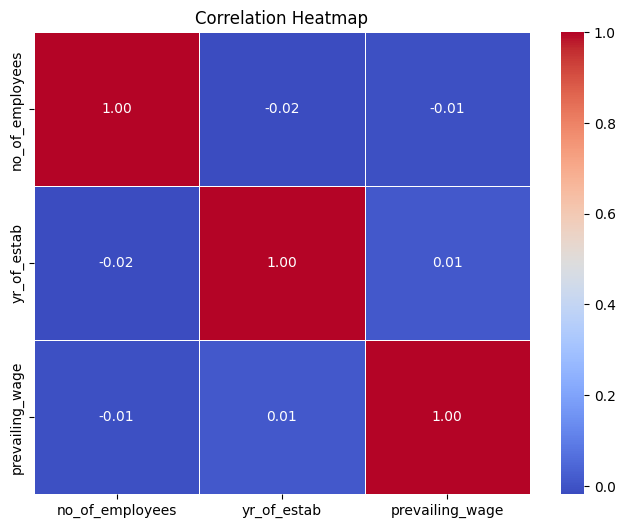

In [ ]:
# Create a heatmap using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
# Set heatmap title
plt.title("Correlation Heatmap")

# Show the heatmap
plt.show()

**Observations:**

In the provided correlation matrix, the correlation coefficients are as follows:

* Correlation between "no_of_employees" and "yr_of_estab" = -0.017770

* Correlation between "no_of_employees" and "prevailing_wage" = -0.009523

* Correlation between "yr_of_estab" and "prevailing_wage" = 0.012342

* The correlation coefficient between these variables is very close to zero

* This indicates a weak correlation or almost no linear relationship

#### **Observation on Education of Employee and Case Status**

case_status            Certified    Denied
education_of_employee                     
High School             0.340351  0.659649
Bachelor's              0.622142  0.377858
Master's                0.786278  0.213722
Doctorate               0.872263  0.127737


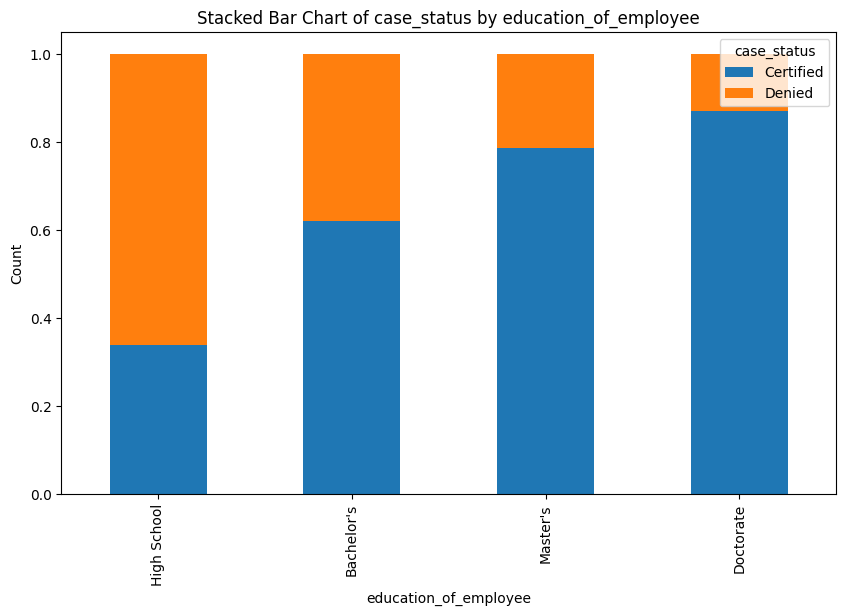

In [ ]:
plot_stacked_bar_chart(data, 'education_of_employee', 'case_status')

**Observations:**

* It seems like the higher the degree one has, the more likely your visa will be accepted

* High school education has less visa certified than those with doctorate education

#### **Corelation between Education of Employee and Region of Employment**

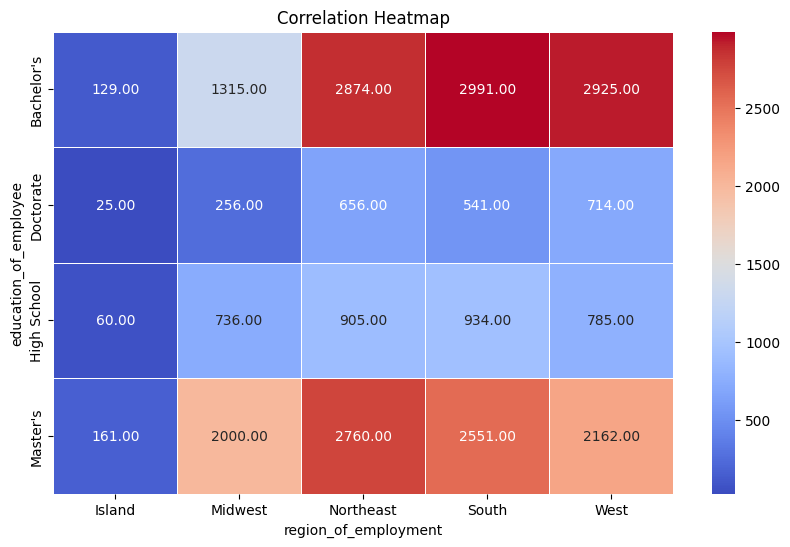

In [ ]:
# Create a heatmap using seaborn
plt.figure(figsize=(10, 6))
sns.heatmap(pd.crosstab(data['education_of_employee'], data['region_of_employment']),
            annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

# Set heatmap title
plt.title("Correlation Heatmap")

# Show the heatmap
plt.show()

**Observations**

* The requirement for the applicants who have passed high school is most in the South region, followed by Northeast region.

* The requirement for Bachelor's is mostly in South region, followed by West region.

* The requirement for Master's is most in Northeast region, followed by South region.

* The requirement for Doctorate's is mostly in West region, followed by Northeast region.

#### **Observation on Education of Employee and Region of Employment**

case_status           Certified    Denied
region_of_employment                     
Island                 0.602667  0.397333
West                   0.622533  0.377467
Northeast              0.629048  0.370952
South                  0.700157  0.299843
Midwest                0.755282  0.244718


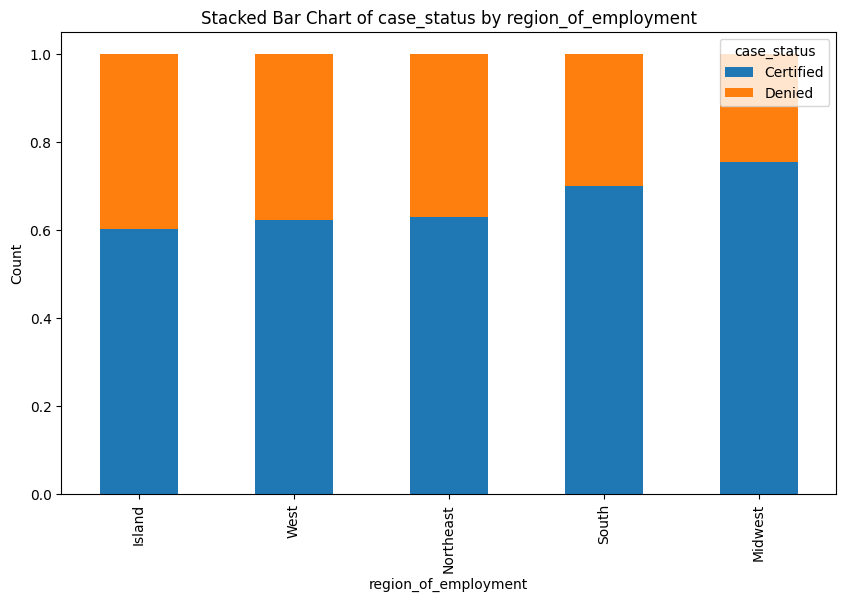

In [ ]:
plot_stacked_bar_chart(data, 'region_of_employment', 'case_status')

**Observations:**

* Midwest sees the highest number of visa certifications but its not the most picked from any level 0f education south sees the next highest

#### **Observation on Continent and Case Status**

case_status    Certified    Denied
continent                         
South America   0.578638  0.421362
North America   0.618773  0.381227
Oceania         0.635417  0.364583
Asia            0.653105  0.346895
Africa          0.720508  0.279492
Europe          0.792337  0.207663


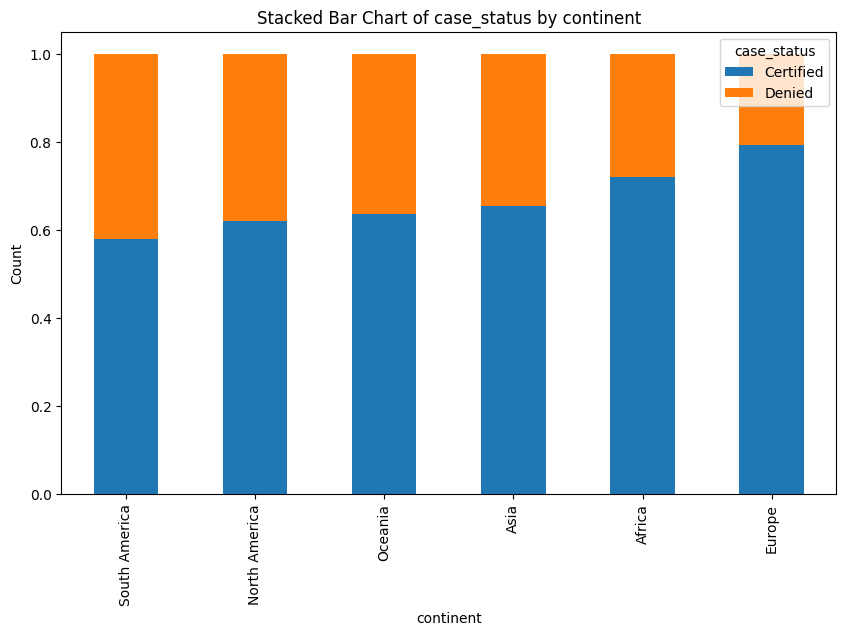

In [ ]:
pd.crosstab(data['continent'], data['case_status'])
plot_stacked_bar_chart(data, 'continent', 'case_status')

**Observations:**

* Europe has the highest visa acceptance followed by Africa

* Asia has the 3rd highest visa certification but has the highest number of application

#### **Observation on Job Experience and case Status**

case_status         Certified    Denied
has_job_experience                     
N                    0.561341  0.438659
Y                    0.744764  0.255236


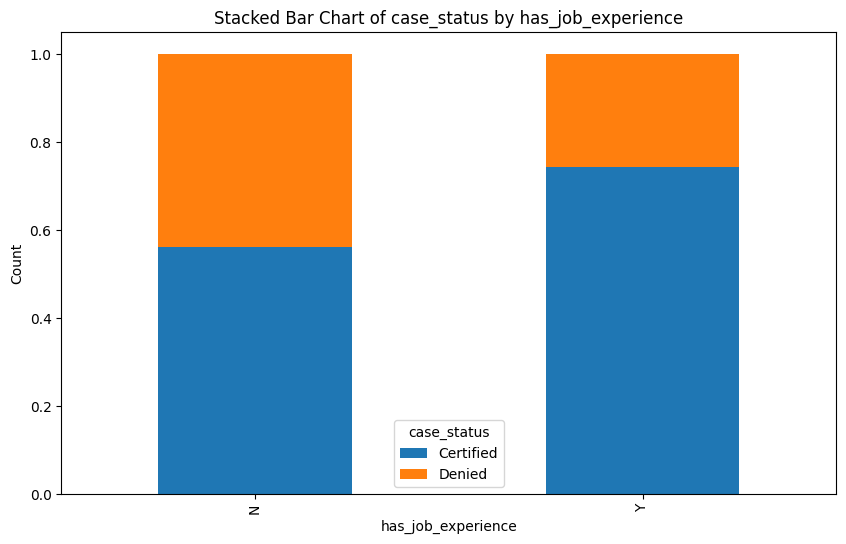

In [ ]:
plot_stacked_bar_chart(data, 'has_job_experience', 'case_status')

**Observations**

* Those that have job experience have a higher chance of their visa being certified with about 74%.

* About 56% of people who didnt have a job experience also got their visa certified.

#### **Obervation on Job Requirement and Job Training**

requires_job_training         N         Y
has_job_experience                       
N                      0.841731  0.158269
Y                      0.914539  0.085461


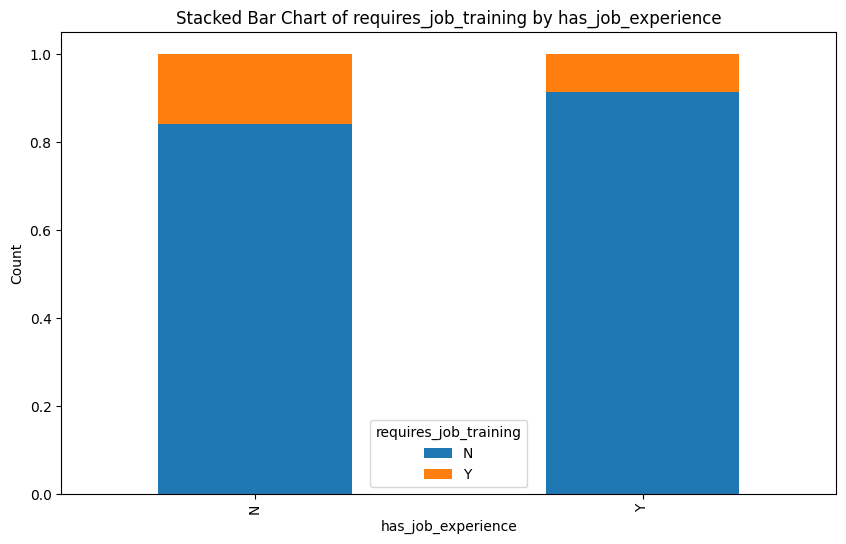

In [ ]:
plot_stacked_bar_chart(data, 'has_job_experience', 'requires_job_training')

**Observations:**

* Most candidates, whether they have job experience or not, do not require job training (blue portion is largest).


* A small portion of candidates in both groups (experienced and non-experienced) still require training (orange portion).


* The difference in training requirement between experienced and non-experienced candidates is not very large — in both cases, training needs are relatively low.

In [ ]:
#functions to plot distributions wrt target

def plot_distributions_with_target(data, predictor_column, target_column):
    """
    Plot distributions of predictor and target columns with respect to the target variable.

    data: DataFrame
    predictor_column: Column name of the predictor variable
    target_column: Column name of the target variable
    """
    plt.figure(figsize=(12, 6))

    # Plot distribution of the predictor variable for each target category
    plt.subplot(1, 3, 1)
    sns.boxplot(x=target_column, y=predictor_column, data=data)
    plt.xlabel(target_column)
    plt.ylabel(predictor_column)
    plt.title(f'Distribution of {predictor_column} wrt {target_column}')

    # Plot distribution of the target variable
    plt.subplot(1, 3, 2)
    sns.histplot(data[target_column], kde=True, color='blue')
    plt.xlabel(target_column)
    plt.ylabel('Frequency')
    plt.title(f'Distribution of {target_column}')

       # Plot histogram of the predictor variable without outliers
    plt.subplot(1, 3, 3)
    sns.histplot(data[predictor_column], kde=True, color='skyblue')
    plt.xlabel(predictor_column)
    plt.ylabel('Frequency')
    plt.title(f'Histogram of {predictor_column}')

    plt.tight_layout()
    plt.show()

#### **Observation on Prevailing Wage and Case Status**

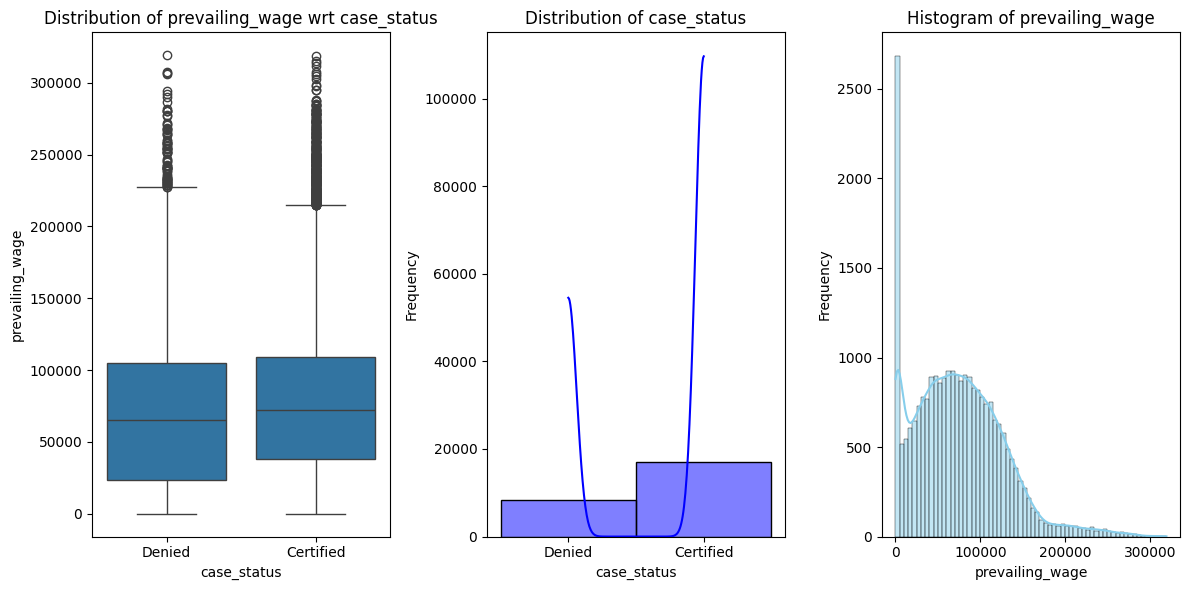

In [ ]:
plot_distributions_with_target(data, 'prevailing_wage', 'case_status')

**Observations:**

• Distribution of wages is right skewed, indicating a long tail of jobs with annual salaries above 200,000
dollars.

• The ratio of approved to denied applications remains equivalent across the range of wages.


In [ ]:
### function to plot distributions wrt target


def distribution_plot_wrt_target(data, predictor, target):

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    target_uniq = data[target].unique()

    axs[0, 0].set_title("Distribution of target for target=" + str(target_uniq[0]))
    sns.histplot(
        data=data[data[target] == target_uniq[0]],
        x=predictor,
        kde=True,
        ax=axs[0, 0],
        color="teal",
        stat="density",
    )

    axs[0, 1].set_title("Distribution of target for target=" + str(target_uniq[1]))
    sns.histplot(
        data=data[data[target] == target_uniq[1]],
        x=predictor,
        kde=True,
        ax=axs[0, 1],
        color="orange",
        stat="density",
    )

    axs[1, 0].set_title("Boxplot w.r.t target")
    sns.boxplot(data=data, x=target, y=predictor, ax=axs[1, 0], palette="gist_rainbow")

    axs[1, 1].set_title("Boxplot (without outliers) w.r.t target")
    sns.boxplot(
        data=data,
        x=target,
        y=predictor,
        ax=axs[1, 1],
        showfliers=False,
        palette="gist_rainbow",
    )

    plt.tight_layout()
    plt.show()


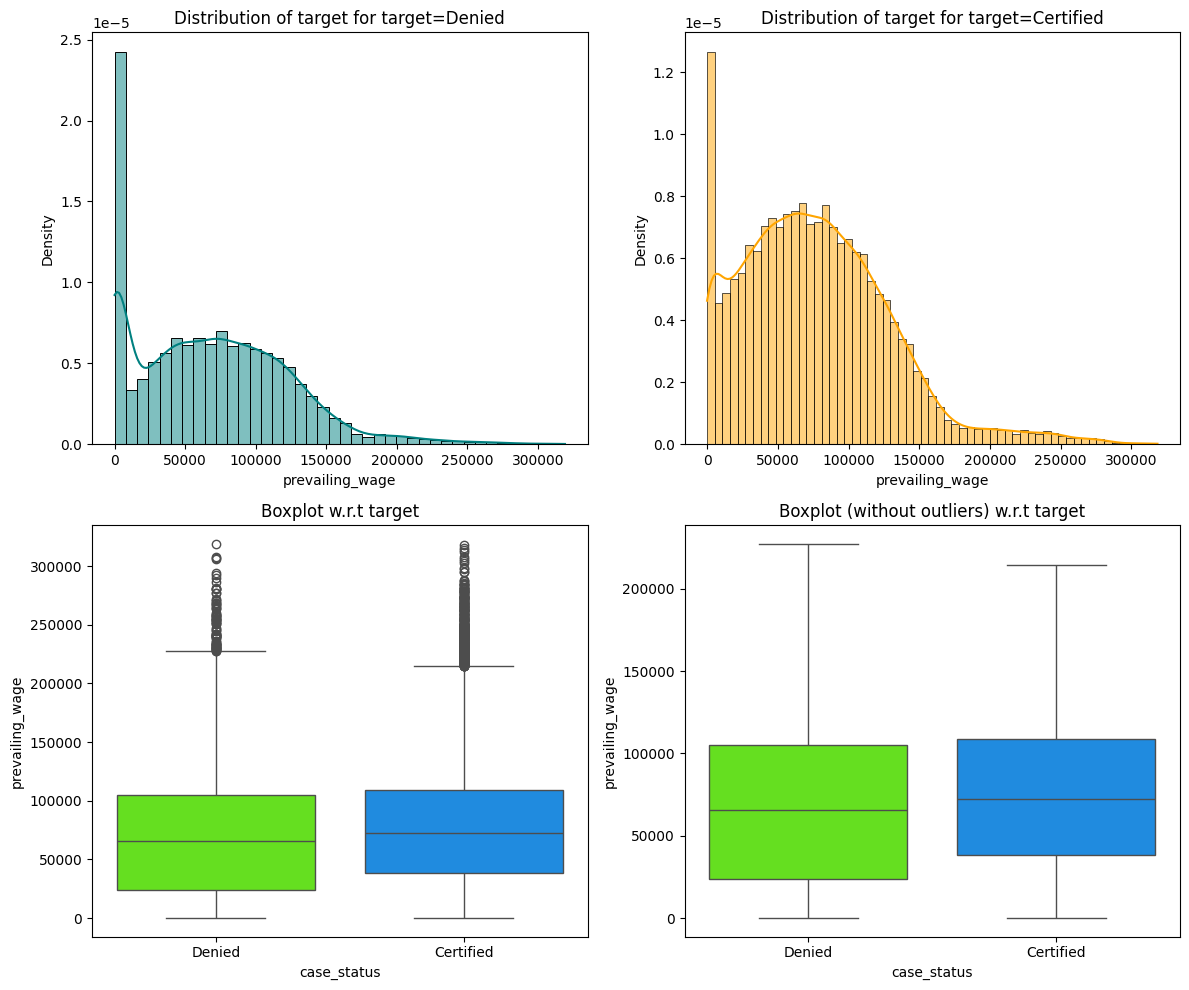

In [ ]:
distribution_plot_wrt_target(data, "prevailing_wage", "case_status")

**Observations:**

* The median wage for the certified applications is slightly higher than the denied application

* The prevailing wage similar across all region.

#### **Observation on Prevailing_Wage and Region of Employement**

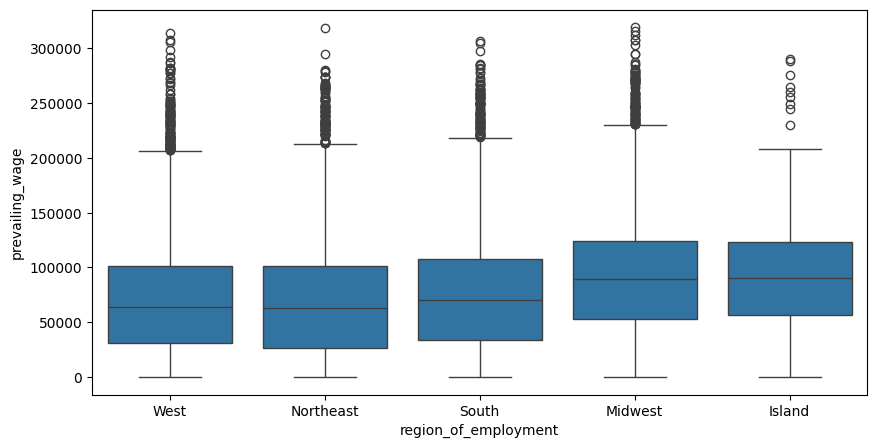

In [ ]:
#prevailing wage across regions
plt.figure(figsize=(10, 5))
sns.boxplot(data=data, x="region_of_employment", y="prevailing_wage")
plt.show()

**Observations:**

* Midwest and island have slightly higher median wages compared to other regions

#### **Observation on Unit Of Wages and Case Status**

case_status   Certified    Denied
unit_of_wage                     
Hour           0.346314  0.653686
Month          0.617978  0.382022
Week           0.621324  0.378676
Year           0.698850  0.301150


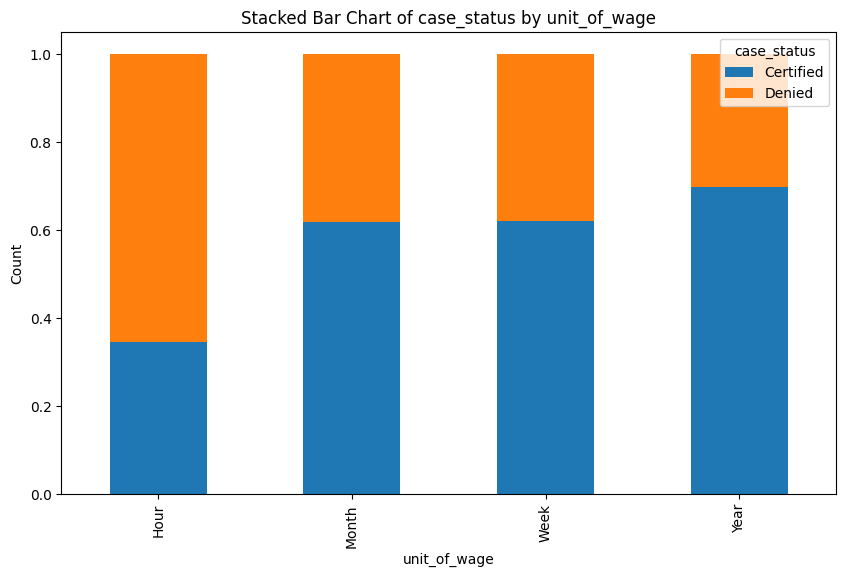

In [ ]:
#which unit of wages is most likely to be certified

plot_stacked_bar_chart(data, 'unit_of_wage', 'case_status')

**Observations:**

* Yearly is most likely to be certified but week and month's percentage of employees certified is almost the same.

#### **Observation on Job Training and Case Study**

case_status            Certified    Denied
requires_job_training                     
N                       0.666459  0.333541
Y                       0.678849  0.321151


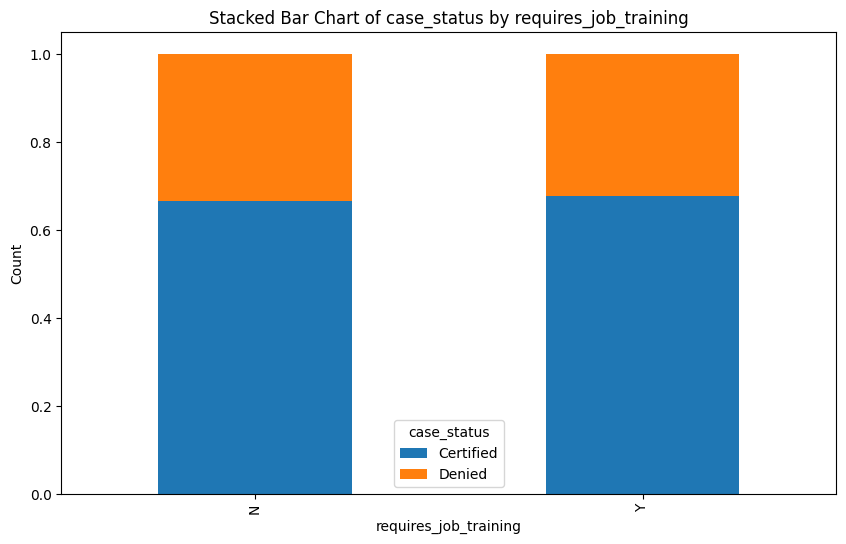

In [ ]:
plot_stacked_bar_chart(data, 'requires_job_training', 'case_status')

**Observations:**

• Job training requirements are not really affected per observation.

#### **Observation on Position Type and Case Status**

case_status         Certified    Denied
full_time_position                     
Y                    0.665832  0.334168
N                    0.685260  0.314740


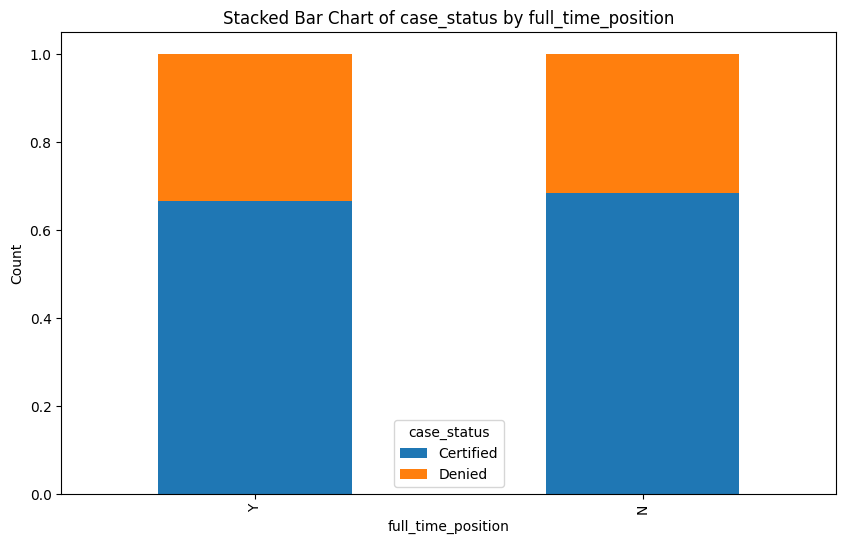

In [ ]:
plot_stacked_bar_chart(data, 'full_time_position', 'case_status')

**Observations:**

* Observations show visa certification not really impact whether its part time or full time.

## **Data Processing**

**Data Preprocessing**

* Missing value treatment (if needed)

* Feature engineering

* Outlier detection and treatment (if needed)

* Preparing data for modeling

*  Any other preprocessing steps (if needed)

### **Missing value treatment**

In [ ]:
df.isnull().sum()

,0
continent,0
education_of_employee,0
has_job_experience,0
requires_job_training,0
no_of_employees,0
yr_of_estab,0
region_of_employment,0
prevailing_wage,0
unit_of_wage,0
full_time_position,0


**Observations:**

* There are no missing value in the given dataset.

### **Feature Engineer**

In [ ]:
# adding a new column, yrs_snc_estab, including years since establishment final year is 2016, when data is complied
df["yrs_since_estab"] =2016-data.yr_of_estab

# dropping yr_of_estab
df.drop("yr_of_estab", axis=1, inplace=True)

# creating a column including equivalent hourly wages - it is assumed that:
df["hourly_wage"] = data["prevailing_wage"]
df.loc[df.unit_of_wage =="Year", "hourly_wage"] =( df.loc[data.unit_of_wage =="Year", "hourly_wage"] /2080.0 )
df.loc[df.unit_of_wage =="Month", "hourly_wage"] =( df.loc[data.unit_of_wage =="Month", "hourly_wage"] /173.0 )
df.loc[df.unit_of_wage =="Week", "hourly_wage"] =( df.loc[data.unit_of_wage =="Week", "hourly_wage"] /40.0 )

# dropping prevailing_wage
df.drop("prevailing_wage", axis=1, inplace=True)

# checking sample rows of updated data
df.sample(10, random_state=1)

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,region_of_employment,unit_of_wage,full_time_position,case_status,yrs_since_estab,hourly_wage
17639,Asia,Bachelor's,Y,N,567,Midwest,Year,Y,Certified,24,12.905245
23951,Oceania,Bachelor's,N,N,619,Midwest,Year,Y,Certified,78,31.932683
8625,Asia,Master's,N,N,2635,South,Hour,Y,Certified,11,887.292100
20206,Asia,Bachelor's,Y,Y,3184,Northeast,Year,Y,Certified,30,23.767212
7471,Europe,Bachelor's,Y,N,4681,West,Year,Y,Denied,88,23.973649
3433,Asia,Bachelor's,Y,N,222,South,Hour,Y,Certified,27,813.726100
24440,Europe,High School,N,Y,3278,South,Year,Y,Denied,22,98.532880
12104,Asia,Master's,Y,N,1359,West,Year,N,Certified,19,97.229346
15656,Asia,Bachelor's,N,N,2081,West,Year,Y,Denied,13,53.708183
23110,North America,Bachelor's,Y,N,854,Northeast,Hour,Y,Denied,18,444.825700


In [ ]:
# checking statistical summary of numeric in updated data
df.describe().T

,count,mean,std,min,25%,50%,75%,max
no_of_employees,25480.0,5667.043210,22877.928848,-26.000000,1022.00000,2109.000000,3504.000000,602069.00000
yrs_since_estab,25480.0,36.590071,42.366929,0.000000,11.00000,19.000000,40.000000,216.00000
hourly_wage,25480.0,94.902995,278.176919,0.048077,22.64806,39.826663,60.012036,7004.39875


**Observations:**

• The oldest employer was established 216 years before the data was complied.

• Madian and mean values of yrs_snc_estab are ~19 years and 36.5, respectively.

• The average hourly wage is 95 approximately.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   continent              25480 non-null  category
 1   education_of_employee  25480 non-null  category
 2   has_job_experience     25480 non-null  category
 3   requires_job_training  25480 non-null  category
 4   no_of_employees        25480 non-null  int64   
 5   region_of_employment   25480 non-null  category
 6   unit_of_wage           25480 non-null  category
 7   full_time_position     25480 non-null  category
 8   case_status            25480 non-null  category
 9   yrs_since_estab        25480 non-null  int64   
 10  hourly_wage            25480 non-null  float64 
dtypes: category(8), float64(1), int64(2)
memory usage: 797.7 KB


### **Outlier detection and treatment**

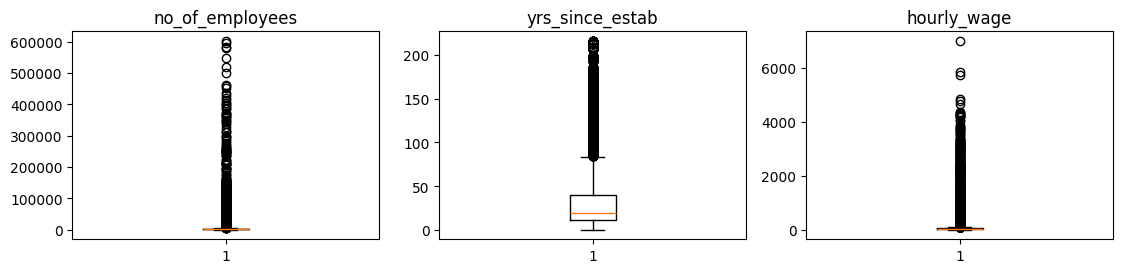

In [ ]:
#creating outlier detection using boxplot

numeric_columns =df.select_dtypes(include=np.number).columns.tolist()
plt.figure(figsize=(15, 10))
for i, variable in enumerate(numeric_columns):
  plt.subplot(4, 4, i +1)
  plt.boxplot(df[variable], whis=1.5)
  plt.tight_layout()
  plt.title(variable)
plt.show()

**Observations:**

Not all the outliers detected based on the 1.5-IQR rule are true outliers, but we will be removing the very large values.

**Treating Outliers**

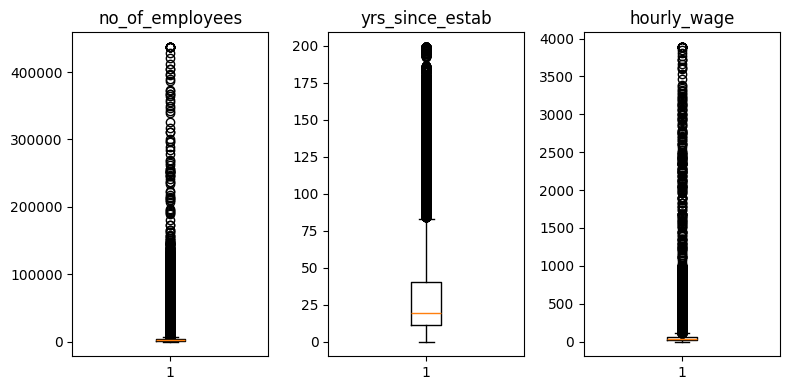

In [ ]:
# replacing outliers in no_of_employees
df.loc[df.no_of_employees > 450000, "no_of_employees"] = df[df.no_of_employees <=450000 ].no_of_employees.max()

# replacing outliers in yrs_since_estab
df.loc[df.yrs_since_estab >200, "yrs_since_estab"] = df[df.yrs_since_estab <= 200 ].yrs_since_estab.max()

# replace outliers in hourly_wage
df.loc[df.hourly_wage >4000, "hourly_wage"] = df[df.hourly_wage <=4000 ].hourly_wage.max()

# using boxplots for distributions

plt.figure(figsize=(8, 4))
for i, variable in enumerate(numeric_columns):
  plt.subplot(1, 3, i +1)
  plt.boxplot(df[variable], whis=1.5) # Changed data to df
  plt.tight_layout()
  plt.title(variable)
plt.show()

In [ ]:
df

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,region_of_employment,unit_of_wage,full_time_position,case_status,yrs_since_estab,hourly_wage
0,Asia,High School,N,N,14513,West,Hour,Y,Denied,9,592.202900
1,Asia,Master's,Y,N,2412,Northeast,Year,Y,Certified,14,40.108486
2,Asia,Bachelor's,N,Y,44444,West,Year,Y,Denied,8,59.133106
3,Asia,Bachelor's,N,N,98,West,Year,Y,Denied,119,40.112514
4,Africa,Master's,Y,N,1082,South,Year,Y,Certified,11,72.070861
...,...,...,...,...,...,...,...,...,...,...,...
25475,Asia,Bachelor's,Y,Y,2601,South,Year,Y,Certified,8,37.063736
25476,Asia,High School,Y,N,3274,Northeast,Year,Y,Certified,10,134.218649
25477,Asia,Master's,Y,N,1121,South,Year,N,Certified,106,70.335986
25478,Asia,Master's,Y,Y,1918,West,Year,Y,Certified,129,41.420563


### **Preparing Data For Modeling**

#### **Replacing 'certified' with 1 and 'denied' with 0**

In [ ]:
df["case_status"] = df["case_status"].apply(lambda x: 1 if x == "Certified" else 0)
df.head()

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,region_of_employment,unit_of_wage,full_time_position,case_status,yrs_since_estab,hourly_wage
0,Asia,High School,N,N,14513,West,Hour,Y,0,9,592.202900
1,Asia,Master's,Y,N,2412,Northeast,Year,Y,1,14,40.108486
2,Asia,Bachelor's,N,Y,44444,West,Year,Y,0,8,59.133106
3,Asia,Bachelor's,N,N,98,West,Year,Y,0,119,40.112514
4,Africa,Master's,Y,N,1082,South,Year,Y,1,11,72.070861


#### **Splitting the Data**

We will use 70% of data for training and 30% for testing.


In [ ]:
#create a dataframe of the predictor feature columns
X = df.drop('case_status',axis=1)
#create a datafrane of the predicted class (1=True, 0=False)
Y = df['case_status']

#generate dummy variables for each categorical variable
X = pd.get_dummies(X, drop_first=True)

#split the data into train and test datasets
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=1)

In [ ]:
#confirm the split
print("{0:0.2f}% data is in training set".format((len(X_train)/len(df.index)) * 100))
print("{0:0.2f}% data is in test set".format((len(X_test)/len(df.index)) * 100))

70.00% data is in training set
30.00% data is in test set


In [ ]:
#confirm the shape of both data sets and the ratio of classes is the same across both train and test datasets
print("Shape of Training set : ", X_train.shape)
print("Shape of test set : ", X_test.shape)
print(' ')
print("Percentage of classes in training set:")
print(y_train.value_counts(normalize=True))
print(' ')
print("Percentage of classes in test set:")
print(y_test.value_counts(normalize=True))

Shape of Training set :  (17836, 21)
Shape of test set :  (7644, 21)
 
Percentage of classes in training set:
case_status
1    0.663602
0    0.336398
Name: proportion, dtype: float64
 
Percentage of classes in test set:
case_status
1    0.677917
0    0.322083
Name: proportion, dtype: float64


## **Bagging - Model Building and Hyperparameter Tuning**

- We'll fit different models on the train data and observe their performance.
- We'll try to improve that performance by tuning some hyperparameters available for that algorithm.
- We'll use GridSearchCv for hyperparameter tuning and `r_2 score` to optimize the model.
- R-square - `Coefficient of determination` is used to evaluate the performance of a regression model. It is the amount of the variation in the output dependent attribute which is predictable from the input independent variables.
- Let's start by creating a function to get model scores, so that we don't have to use the same codes repeatedly.

In [ ]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn
def model_performance_classification_sklearn(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "Accuracy": acc,
            "Recall": recall,
            "Precision": precision,
            "F1": f1,
        },
        index=[0],
    )

    return df_perf

In [ ]:
def confusion_matrix_sklearn(model, predictors, target):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    y_pred = model.predict(predictors)
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

### **Decision Tree Model**

We will build our model using the DecisionTreeClassifier function, using default 'gini' criteria to split.

In [ ]:
dtree = DecisionTreeClassifier(criterion="gini", random_state=1,)
dtree.fit(X_train, y_train)


DecisionTreeClassifier(random_state=1)

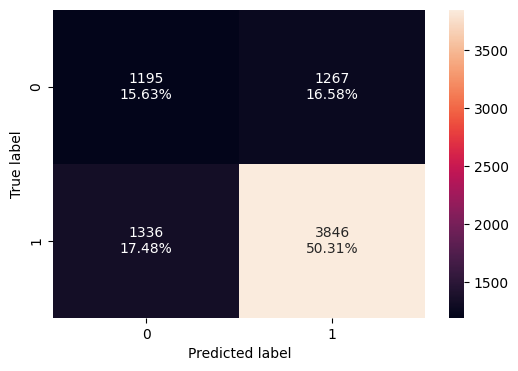

In [ ]:
#create a confusion matrix of the classifier's performance on the testing data
confusion_matrix_sklearn(dtree, X_test, y_test)


In [ ]:
dtree_model_train_perf=model_performance_classification_sklearn(dtree, X_train, y_train)
print("Training performance \n",dtree_model_train_perf)

Training performance 
    Accuracy  Recall  Precision   F1
0       1.0     1.0        1.0  1.0


In [ ]:
dtree_model_test_perf=model_performance_classification_sklearn(dtree, X_test, y_test)
print("Testing performance \n",dtree_model_test_perf)

Testing performance 
    Accuracy    Recall  Precision        F1
0  0.659471  0.742184     0.7522  0.747159


**Observation:**

• Decision tree model performs well for the training data set and all performance metrics, i.e., accuracy, recall, precision, and F1-score are 1.00.

• However, on the test set performance is not that good (F1-score is 0.75 approximately) indicating the model is overfitting. As a result, there is need for hyperparameter tuning through grid search.

#### **Decision Tree Classifier with Hyperparameter Tuning**

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer # Import make_scorer

# choosing type of classifier
tuning_decision_tree =DecisionTreeClassifier(random_state=1)

# form grid of parameters to search in
grid_para ={
    "class_weight": ["balanced", None],
    "max_depth": np.arange(2, 20, 2),
    "max_leaf_nodes": np.arange(2, 20, 2),
    "min_samples_split": [50, 100, 150, 200],
    "min_impurity_decrease": [0.0001, 0.001, 0.01], }

# setting type of score used to evaluate performance search
scorer =make_scorer(f1_score)

# running GridSearch
grid_obj = GridSearchCV(tuning_decision_tree, grid_para, scoring=scorer, cv =5)
grid_obj =grid_obj.fit(X_train, y_train)

# setting classifer to best combination of parameters
tuning_decision_tree =grid_obj.best_estimator_

# fitting best decision tree to training data
tuning_decision_tree.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=np.int64(4), max_leaf_nodes=np.int64(14),
                       min_impurity_decrease=0.0001, min_samples_split=50,
                       random_state=1)

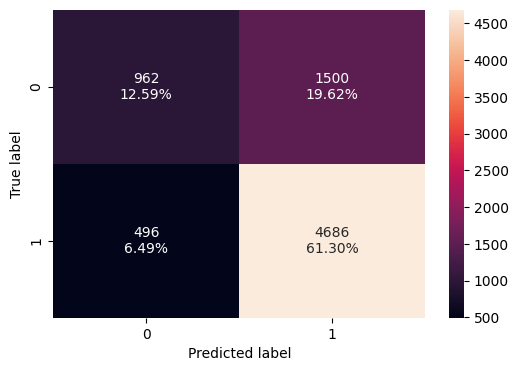

In [ ]:
#create a confusion matrix of the classifier's performance on the testing data
confusion_matrix_sklearn(tuning_decision_tree, X_test,y_test)

In [ ]:
dtree_estimator_model_train_perf=model_performance_classification_sklearn(tuning_decision_tree, X_train,y_train)
print("Training performance \n",dtree_estimator_model_train_perf)

Training performance 
    Accuracy    Recall  Precision        F1
0  0.731778  0.907317    0.74442  0.817836


In [ ]:
dtree_estimator_model_test_perf=model_performance_classification_sklearn(tuning_decision_tree, X_test, y_test)
print("Testing performance \n",dtree_estimator_model_test_perf)

Testing performance 
    Accuracy    Recall  Precision        F1
0   0.73888  0.904284   0.757517  0.824419


**Observation:**

• The turned decision tree model performs equally well overall on the training and testing datasets, indicating that the model is not overfitting.

• F1-score for test set has been increased from approximately 0.75 for the initial model to 0.82 approximately for the tuned model.

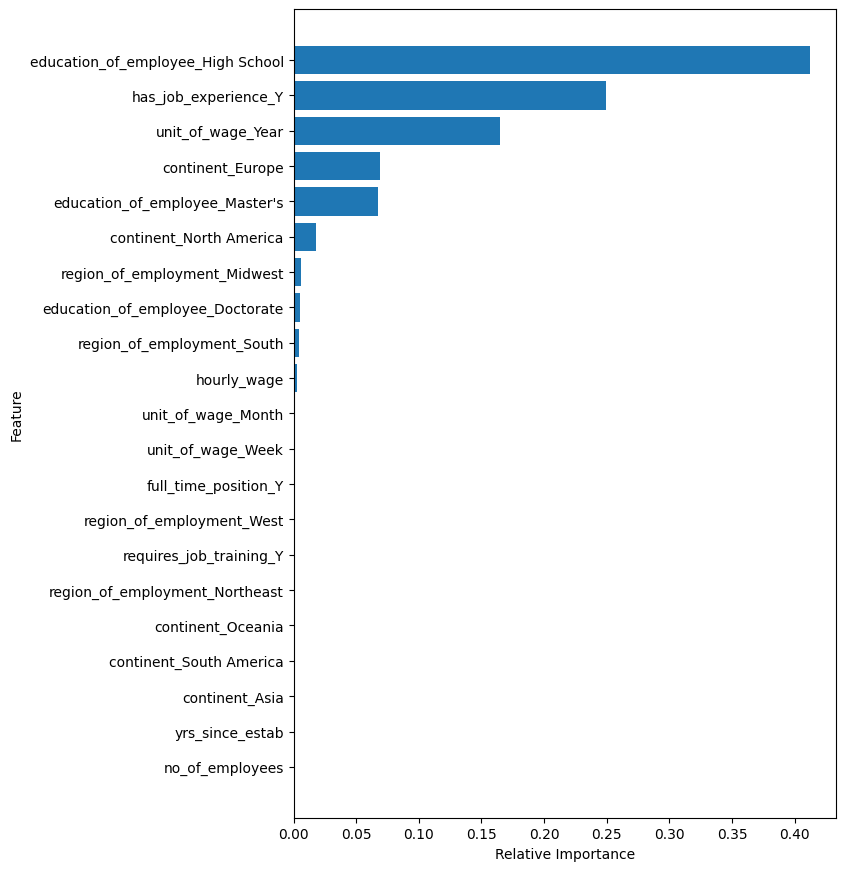

In [ ]:
# creating a list of column names - features of tree
column_names =list(X.columns)

# Check importances of various features of tuned tree
importances =tuning_decision_tree.feature_importances_
indices =np.argsort(importances)

plt.figure(figsize=(7, 0.5*len(column_names)))
plt.barh(range(len(indices)), importances[indices], align="center")
plt.yticks(range(len(indices)), [column_names[i] for i in indices])
plt.xlabel("Relative Importance", fontsize=10)
plt.ylabel("Feature", fontsize=10)
plt.show()

**Observation:**

• Four top independent variables of importance in the tuned decision tree model are education_of_employee_high_school, has_job_experience, unit_of_wage_year, and continent Europe.

### **Bagging Classifier**

In [ ]:
# using function BaggingClassifier from sklearn to build model
bagging =BaggingClassifier(random_state=1)
bagging.fit(X_train, y_train)

BaggingClassifier(random_state=1)

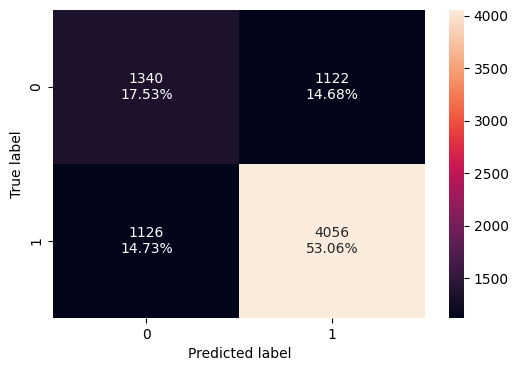

In [ ]:
#create a confusion matrix of the classifier's performance on the testing data
confusion_matrix_sklearn(bagging, X_test, y_test)

In [ ]:
bagging_model_train_perf=model_performance_classification_sklearn(bagging, X_train, y_train)
print("Training performance \n",bagging_model_train_perf)

Training performance 
    Accuracy    Recall  Precision        F1
0  0.985311  0.986397   0.991423  0.988904


In [ ]:
bagging_model_test_perf=model_performance_classification_sklearn(bagging, X_test, y_test)
print("Testing performance \n",bagging_model_test_perf)

Testing performance 
    Accuracy    Recall  Precision        F1
0  0.705913  0.782709   0.783314  0.783012


**Observations:**

* Model has a little better performance on the test data set compared to the initial decision tree not turned model.

* Looking into the high-performance metrics for the training data set, the model is overfitting and needs hyperparameter tuning.

#### **Bagging Classifier with Hyperparameter Tuning**

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer
# choosing type of classifier

tuning_bagging =BaggingClassifier(random_state=1)

# form grid of parameters to search in
grid_para ={
    "max_samples": [0.7, 0.8, 0.9, 1.0],
    "max_features": [0.7, 0.8, 0.9, 1.0],
    "n_estimators": np.arange(50, 100, 10), }

# setting type of score used to evaluate performance search
scorer = make_scorer(f1_score)

# runing GridSearch
grid_obj =GridSearchCV(tuning_bagging, grid_para, scoring=scorer, cv=5)
grid_obj =grid_obj.fit(X_train, y_train)

# setting classifer to best combination of parameters
tuning_bagging =grid_obj.best_estimator_

# fitting best decision tree to training data
tuning_bagging.fit(X_train, y_train)
BaggingClassifier(max_features=0.7, max_samples=0.7, n_estimators=60, random_state=1)

BaggingClassifier(max_features=0.7, max_samples=0.7, n_estimators=60,
                  random_state=1)

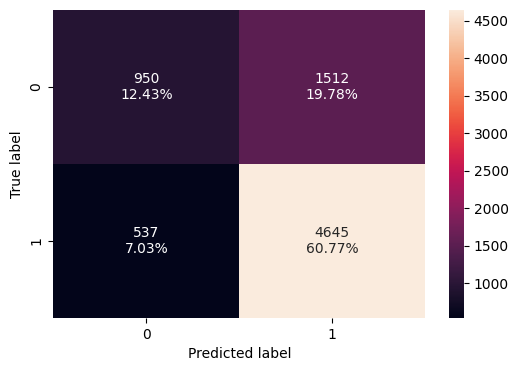

In [ ]:
#create a confusion matrix of the classifier's performance on the testing data
confusion_matrix_sklearn(tuning_bagging, X_test,y_test)

In [ ]:
bagging_estimator_model_train_perf=model_performance_classification_sklearn(tuning_bagging, X_train,y_train)
print("Training performance \n",bagging_estimator_model_train_perf)

Training performance 
    Accuracy  Recall  Precision        F1
0  0.998879     1.0   0.998313  0.999156


In [ ]:
bagging_estimator_model_test_perf=model_performance_classification_sklearn(tuning_bagging, X_test, y_test)
print("Testing performance \n",bagging_estimator_model_test_perf)

Testing performance 
    Accuracy    Recall  Precision        F1
0  0.731947  0.896372   0.754426  0.819296


**Observations:**

* The tuned model's performance on the test data set has been improved a bit compared to the initial bagging model - the F1-score has been increased from 0.78 for the initial model to 0.82 for the tuned model.

* Model seems to be overfitting in the training data.

### **Random Forest Classifier**

In [ ]:
# using function RandomForestClassifier from sklearn to build model
random_forest =RandomForestClassifier(random_state=1)
random_forest.fit(X_train, y_train)

RandomForestClassifier(random_state=1)

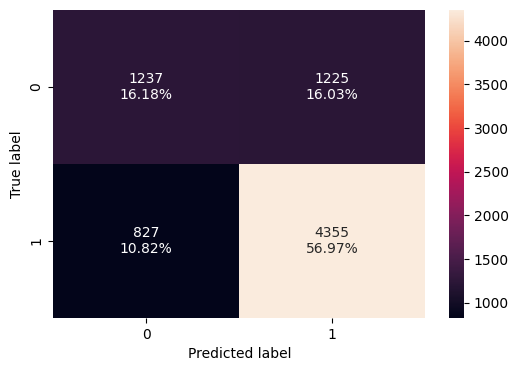

In [ ]:
#create a confusion matrix of the classifier's performance on the testing data
confusion_matrix_sklearn(random_forest,X_test,y_test)

In [ ]:
rf_model_train_perf=model_performance_classification_sklearn(random_forest,X_train,y_train)
print("Training performance \n",rf_model_train_perf)

Training performance 
    Accuracy  Recall  Precision        F1
0  0.999944     1.0   0.999916  0.999958


In [ ]:
rf_model_test_perf=model_performance_classification_sklearn(random_forest,X_test,y_test)
print("Testing performance \n",rf_model_test_perf)

Testing performance 
    Accuracy    Recall  Precision        F1
0  0.731554  0.840409   0.780466  0.809329


**Observations:**

* Similar to the models above, this Random Forest is also overfit to the training dataset but has the highest F1 score so far.

#### **Random Forest Classifier with Hyperparameter Tuning**

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer
# # choosing type of classifier
tuning_random_forest =RandomForestClassifier(oob_score=True, random_state= 1)

# form grid of parameters to search in
grid_para ={
    "class_weight": ["balanced", None],
    "max_samples": [0.7, 0.8, 0.9, 1.0],
    "max_depth": np.arange(1, 5, 1),
    "max_features": ["sqrt", "log2"],
    "min_samples_split": [50, 100, 150, 200],
    "n_estimators": np.arange(20, 100, 20), }

# setting type of score used to evaluate performance search
scorer = make_scorer(f1_score)

# runing GridSearch
grid_obj =GridSearchCV(tuning_random_forest, grid_para, scoring=scorer, cv =5)
grid_obj =grid_obj.fit(X_train, y_train)

# setting classifer to best combination of parameters
tuning_random_forest =grid_obj.best_estimator_

# fitting best decision tree to training data

tuning_random_forest.fit(X_train, y_train)

RandomForestClassifier(max_depth=np.int64(4), max_samples=1.0,
                       min_samples_split=200, n_estimators=np.int64(80),
                       oob_score=True, random_state=1)

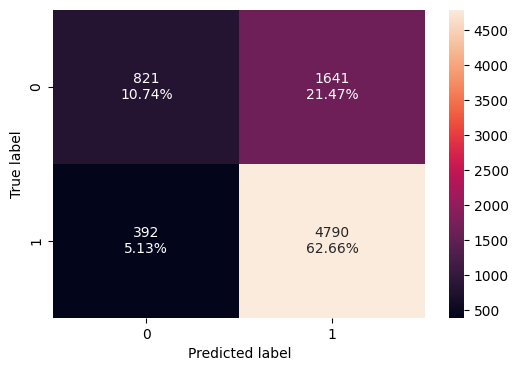

In [ ]:
#create a confusion matrix of the classifier's performance on the testing data
confusion_matrix_sklearn(tuning_random_forest, X_test,y_test)

In [ ]:
rf_estimator_model_train_perf=model_performance_classification_sklearn(tuning_random_forest, X_train,y_train)
print("Training performance \n",rf_estimator_model_train_perf)

Training performance 
    Accuracy    Recall  Precision        F1
0  0.729984  0.927171   0.735129  0.820057


In [ ]:
rf_estimator_model_test_perf=model_performance_classification_sklearn(tuning_random_forest, X_test, y_test)
print("Testing performance \n",rf_estimator_model_test_perf)

Testing performance 
    Accuracy    Recall  Precision        F1
0   0.73404  0.924354    0.74483  0.824938


**Observations:**

*  Observation shows performance metrics are close for both training and test data sets, showing the model is no longer overfitting.

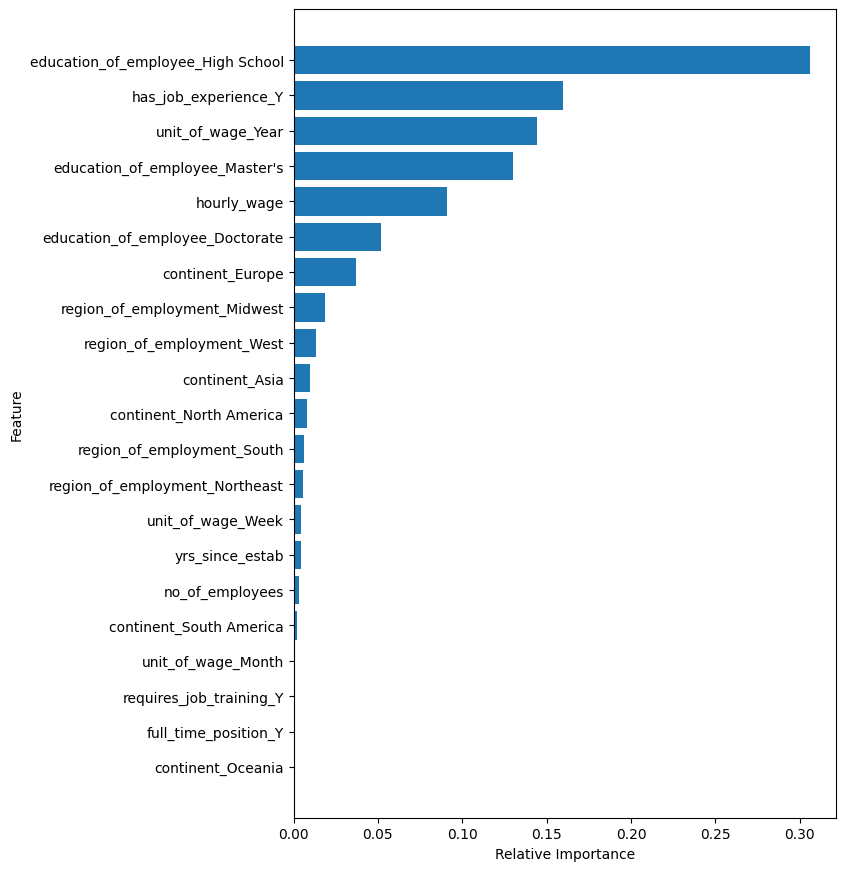

In [ ]:
# checking the importances of various features of tuned random forest class ifier
column_names =list(X.columns) # Define column_names
importances =tuning_random_forest.feature_importances_
indices =np.argsort(importances)
plt.figure(figsize=(7, 0.5*len(column_names)))
plt.barh(range(len(indices)), importances[indices], align="center")
plt.yticks(range(len(indices)), [column_names[i] for i in indices]) # Corrected syntax here
plt.xlabel("Relative Importance", fontsize=10)
plt.ylabel("Feature", fontsize=10)
plt.show()

**Observations:**

* Top independent features of importance in the tuned random forest mode are education_of_employee_high_school, has_job_experience_Y, unit_of_wage_year, and education_of_the_emoloyee_masters.

## **Boosting - Model Building and Hyperparameter Tuning**

### **AdaBoost Classifier**

In [ ]:
# using function AdaBoostClassifier from sklearn to build model

ada_boost =AdaBoostClassifier(random_state=1)
ada_boost.fit(X_train, y_train)

AdaBoostClassifier(random_state=1)

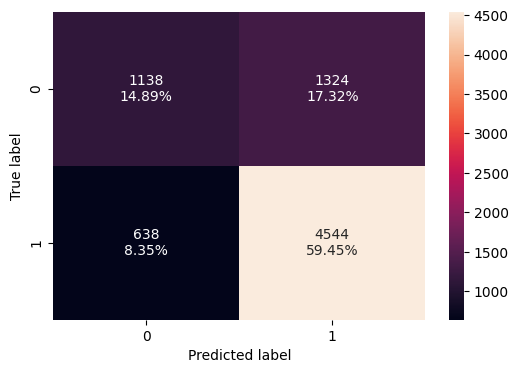

In [ ]:
#create a confusion matrix of the classifier's performance on the testing data
confusion_matrix_sklearn(ada_boost,X_test,y_test)

In [ ]:
ab_classifier_model_train_perf = model_performance_classification_sklearn(ada_boost,X_train,y_train)
print("Training performance \n",ab_classifier_model_train_perf)

Training performance 
    Accuracy    Recall  Precision        F1
0  0.738731  0.877746   0.763785  0.816809


In [ ]:
ab_classifier_model_test_perf = model_performance_classification_sklearn(ada_boost,X_test,y_test)
print("Testing performance \n",ab_classifier_model_test_perf)

Testing performance 
    Accuracy    Recall  Precision        F1
0  0.743328  0.876882   0.774369  0.822443


**Observations:**

* This AdaBoost classifer performs equally well on the training and testing datasets, indicating that the model is not overfit.

* Hyperparameter tuning may help to improve the model's performance as the metrics for the training and test data sets are very close.

#### **AdaBoost Classifier with Hyperparameter Tuning**

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer
# choosing type of classifier
tuning_ada_boost =AdaBoostClassifier(random_state=1)

# form grid of parameters to search in
grid_para ={
    "estimator": [ DecisionTreeClassifier(max_depth=1), DecisionTreeClassifier(max_depth=2), DecisionTreeClassifier(max_depth=3), ],
    "n_estimators": np.arange(20, 100, 20),
    "learning_rate": np.arange(0.2, 1.1, 0.2), }

# setting type of score used to evaluate performance search
scorer =make_scorer(f1_score) # runing GridSearch
grid_obj =GridSearchCV(tuning_ada_boost, grid_para, scoring=scorer, cv=5)
grid_obj = grid_obj.fit(X_train, y_train)

# setting classifer to best combination of parameters
tuning_ada_boost =grid_obj.best_estimator_

# fitting best decision tree to training data
tuning_ada_boost.fit(X_train, y_train)

AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=3),
                   learning_rate=np.float64(0.2), n_estimators=np.int64(60),
                   random_state=1)

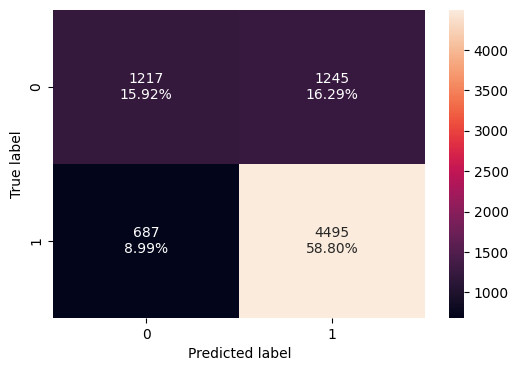

In [ ]:
#create a confusion matrix of the classifier's performance on the testing data
confusion_matrix_sklearn(tuning_ada_boost, X_test,y_test)

In [ ]:
abc_tuned_model_train_perf=model_performance_classification_sklearn(tuning_ada_boost, X_train,y_train)
print("Training performance \n",abc_tuned_model_train_perf)

Training performance 
    Accuracy    Recall  Precision        F1
0  0.745907  0.872423   0.773599  0.820044


In [ ]:
abc_tuned_model_test_perf=model_performance_classification_sklearn(tuning_ada_boost, X_test, y_test)
print("Testing performance \n",abc_tuned_model_test_perf)

Testing performance 
    Accuracy    Recall  Precision        F1
0  0.747253  0.867426   0.783101  0.823109


**Observations:**

* Significant changes were not observed in the model performance after tuning

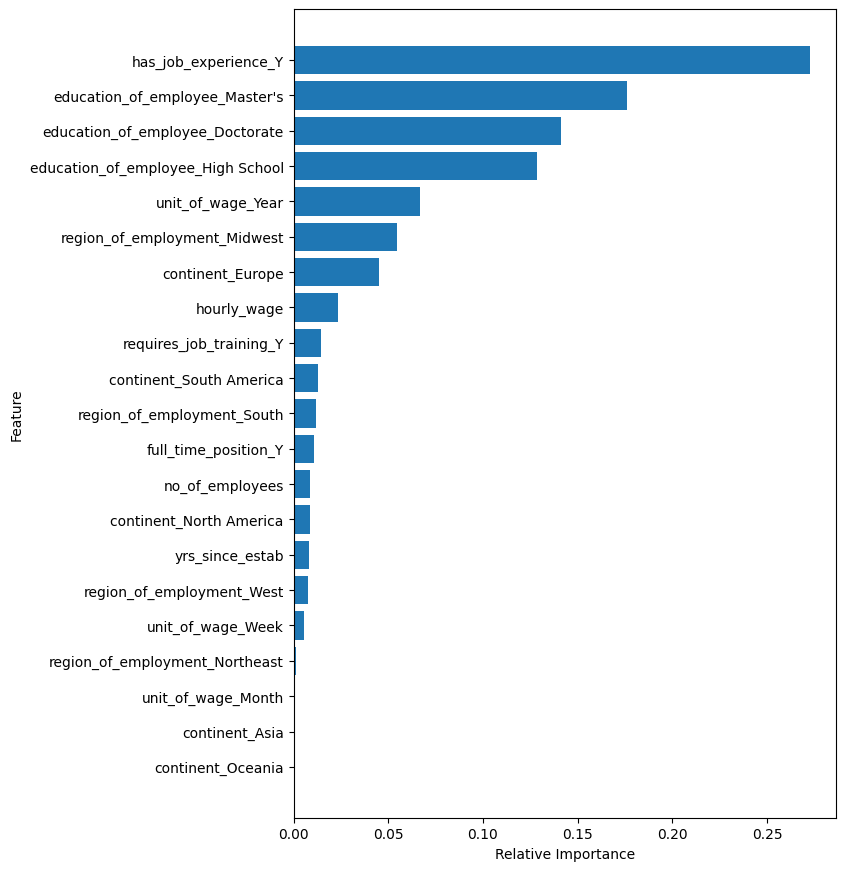

In [ ]:
# checking importances of various features of tuned AdaBoost classifier
column_names = list(X.columns)
importances =tuning_ada_boost.feature_importances_
indices =np.argsort(importances)
plt.figure(figsize=(7, 0.5*len(column_names)))
plt.barh(range(len(indices)), importances[indices], align="center")
plt.yticks(range(len(indices)), [column_names[i] for i in indices])
plt.xlabel("Relative Importance", fontsize=10)
plt.ylabel("Feature", fontsize=10)
plt.show()

**Observations:**

* The top three independent features of importance in the tuned AdaBoost model are has_job_experience_Y, education_of_employee_Master's, education_of_employee_Doctorate.

### **Gradient Boosting Classifier**

In [ ]:
# using function GradientBoostingClassifier from sklearn to build model
gradient_boost =GradientBoostingClassifier(random_state=1)
gradient_boost.fit(X_train, y_train)

GradientBoostingClassifier(random_state=1)

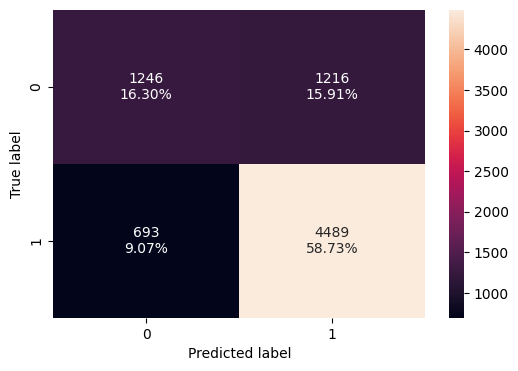

In [ ]:
#create a confusion matrix of the classifier's performance on the testing data
confusion_matrix_sklearn(gradient_boost, X_test,y_test)

In [ ]:
gbc_classifier_model_train_perf = model_performance_classification_sklearn(gradient_boost,X_train,y_train)
print("Training performance \n",gbc_classifier_model_train_perf)

Training performance 
    Accuracy    Recall  Precision        F1
0  0.755326  0.874789   0.782261  0.825941


In [ ]:
gbc_classifier_model_test_perf = model_performance_classification_sklearn(gradient_boost,X_test,y_test)
print("Training performance \n",gbc_classifier_model_test_perf)

Training performance 
    Accuracy    Recall  Precision        F1
0  0.750262  0.866268   0.786854  0.824653


**Observations:**

* Both the training and test data sets do not show overfitting.
* The F1-score for both training and test data sets is above 0.82, which looks good.

#### **Gradient Boosting Classifier with Hyperparameter Tuning**

In [ ]:
# choosing type of classifier
tuning_gradient_boost =GradientBoostingClassifier( init=AdaBoostClassifier(random_state=1), random_state=1 )

# form grid of parameters to search in
grid_para ={
    "subsample": [0.7, 0.8, 0.9],
    "max_features": [0.8, 0.9, 1.0],
    "n_estimators": np.arange(20, 100, 20),
    "learning_rate": np.arange(0.2, 1.1, 0.2), }

# setting type of score used to evaluate performance search
scorer =make_scorer(f1_score) # running GridSearch
grid_obj =GridSearchCV(tuning_gradient_boost, grid_para, scoring=scorer, cv=5)
grid_obj =grid_obj.fit(X_train, y_train)

# Set classifer to best combination of parameters
tuning_gradient_boost =grid_obj.best_estimator_
# Fit best decision tree to training data
tuning_gradient_boost.fit(X_train, y_train)

GradientBoostingClassifier(init=AdaBoostClassifier(random_state=1),
                           learning_rate=np.float64(0.2), max_features=0.8,
                           n_estimators=np.int64(20), random_state=1,
                           subsample=0.8)

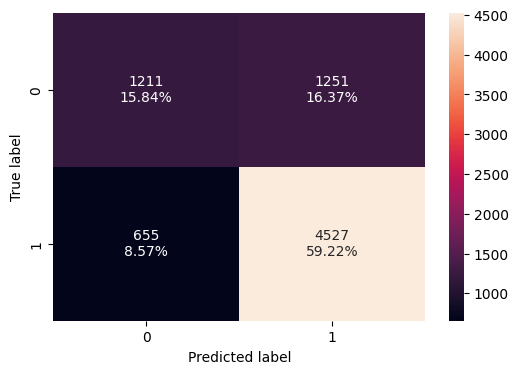

In [ ]:
#create a confusion matrix of the classifier's performance on the testing data
confusion_matrix_sklearn(tuning_gradient_boost, X_test,y_test)

In [ ]:
gb_tuned_model_train_perf=model_performance_classification_sklearn(tuning_gradient_boost, X_train,y_train)
print("Training performance \n",gb_tuned_model_train_perf)

Training performance 
    Accuracy    Recall  Precision       F1
0  0.750056  0.878422    0.77497  0.82346


In [ ]:
gb_tuned_model_test_perf=model_performance_classification_sklearn(tuning_gradient_boost, X_test, y_test)
print("Testing performance \n",gb_tuned_model_test_perf)

Testing performance 
    Accuracy    Recall  Precision        F1
0  0.750654  0.873601   0.783489  0.826095


**Observations:**

*  Hyperparameter tuning slightly improves the performance of the gradient boosting model.

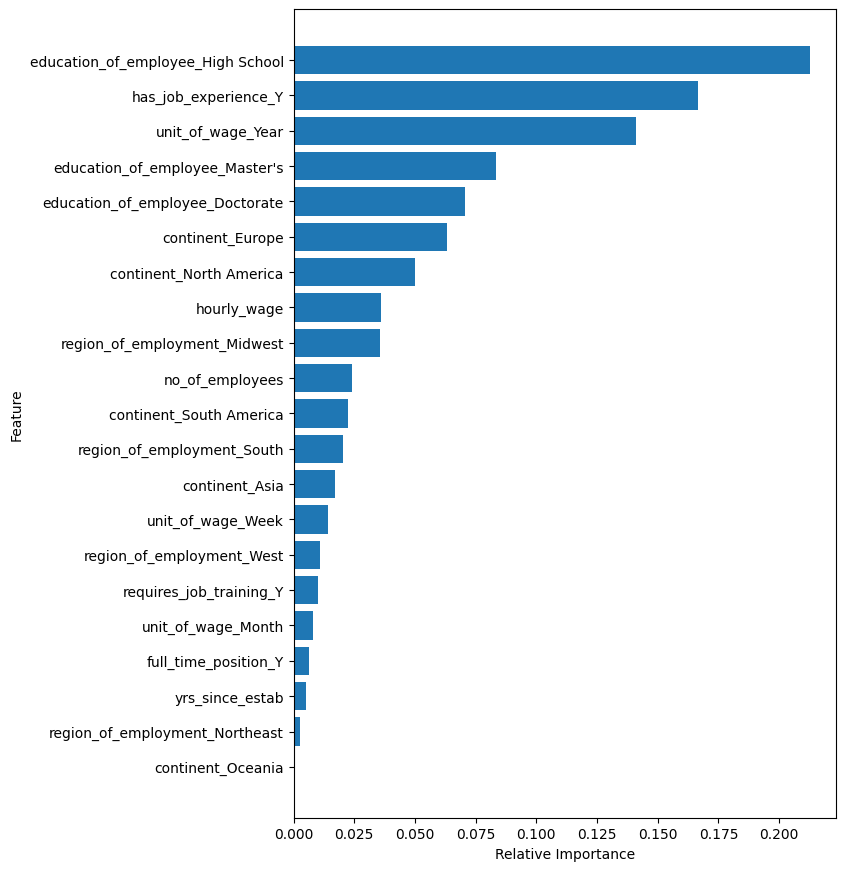

In [ ]:
# checking importances of various features of tuned gradient boosting class ifier
importances =tuning_gradient_boost.feature_importances_
column_names =list(X.columns)
indices =np.argsort(importances)
plt.figure(figsize=(7, 0.5*len(column_names)))
plt.barh(range(len(indices)), importances[indices], align="center")
plt.yticks(range(len(indices)), [column_names[i] for i in indices])
plt.xlabel("Relative Importance", fontsize=10)
plt.ylabel("Feature", fontsize=10)
plt.show()

**Observations:**

* The top three independent features of importance in the tuned gradient boosting model are education_of_employee_high_school, has_job_experience, unit_of_wage_year.

### **XGBoost Classifier**


In [ ]:
# using function XGBClassifier from xgboost to build model
xg_boost =XGBClassifier(eval_metric="logloss", random_state=1)
xg_boost.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

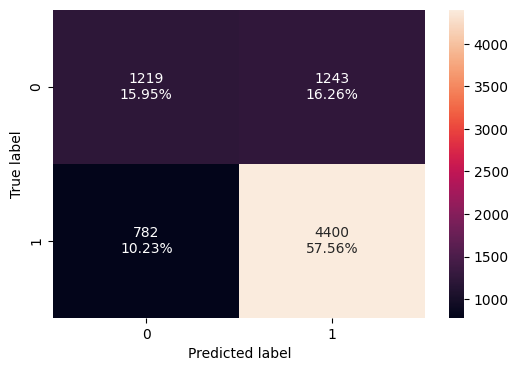

In [ ]:
#create a confusion matrix of the classifier's performance on the testing data
confusion_matrix_sklearn(xg_boost, X_test,y_test)

In [ ]:
xgb_classifier_model_train_perf = model_performance_classification_sklearn(xg_boost,X_train,y_train)
print("Training performance \n",xgb_classifier_model_train_perf)

Training performance 
    Accuracy    Recall  Precision       F1
0  0.837295  0.928439   0.842456  0.88336


In [ ]:
xgb_classifier_model_test_perf = model_performance_classification_sklearn(xg_boost,X_test,y_test)
print("Training performance \n",xgb_classifier_model_test_perf)

Training performance 
    Accuracy    Recall  Precision        F1
0  0.735086  0.849093   0.779727  0.812933


**Observations:**
* This XGBoost classifer performs equally well on the training and testing datasets, indicating that the model is not overfit.
* Hyperparameter tuning could be used to see if there will be any improvement with the model as its looks slightly overfitting.

#### **XGBoost Classifier with Hyperparameter Tuning**

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer
# choosing type of classifier
tuning_xg_boost =XGBClassifier(eval_metric="logloss", random_state=1)
# form grid of parameters to search in
grid_para ={ "subsample": [0.6, 0.8], "scale_pos_weight": [1, 2], "gamma": [3, 5], "colsample_bytree": [0.6, 0.8], "colsample_bylevel": [0.6, 0.8], "n_estimators": [50, 100], "learning_rate": [0.1, 0.2], }
# setting type of score used to evaluate performance search
scorer =make_scorer(f1_score)

# run GridSearch
grid_obj =GridSearchCV(tuning_xg_boost, grid_para, scoring=scorer, cv=5)
grid_obj =grid_obj.fit(X_train, y_train)

# setting classifer to best combination of parameters
tuning_xg_boost =grid_obj.best_estimator_

# fitting best decision tree to training data
tuning_xg_boost.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=0.6, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=3,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=50, n_jobs=None,
              num_parallel_tree=None, ...)

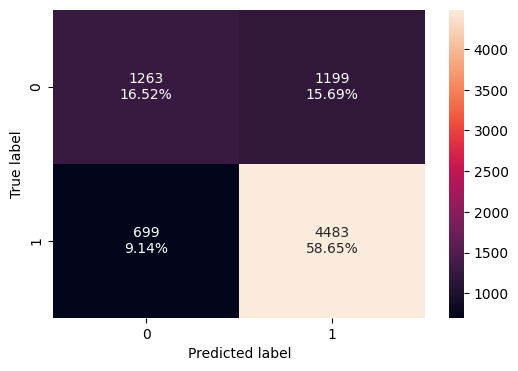

In [ ]:
# creating confusion matrix based on test data set
confusion_matrix_sklearn(tuning_xg_boost, X_test,y_test)

In [ ]:
xgb_tuned_model_train_perf=model_performance_classification_sklearn(tuning_xg_boost, X_train,y_train)
print("Training performance \n",xgb_tuned_model_train_perf)

Training performance 
    Accuracy    Recall  Precision        F1
0   0.75841  0.874958   0.785438  0.827785


In [ ]:
from os import XATTR_REPLACE
xgb_tuned_model_test_perf=model_performance_classification_sklearn(tuning_xg_boost, X_test, y_test)
print("Testing performance \n",xgb_tuned_model_test_perf)

Testing performance 
    Accuracy   Recall  Precision        F1
0  0.751701  0.86511   0.788983  0.825295


**Observations:**

* The model performance on the test set was improved a bit after tuning, increasing the F1-score from 0.812 to 0.825. Tuned XGBoost model provides close performances on both the test and training data sets.

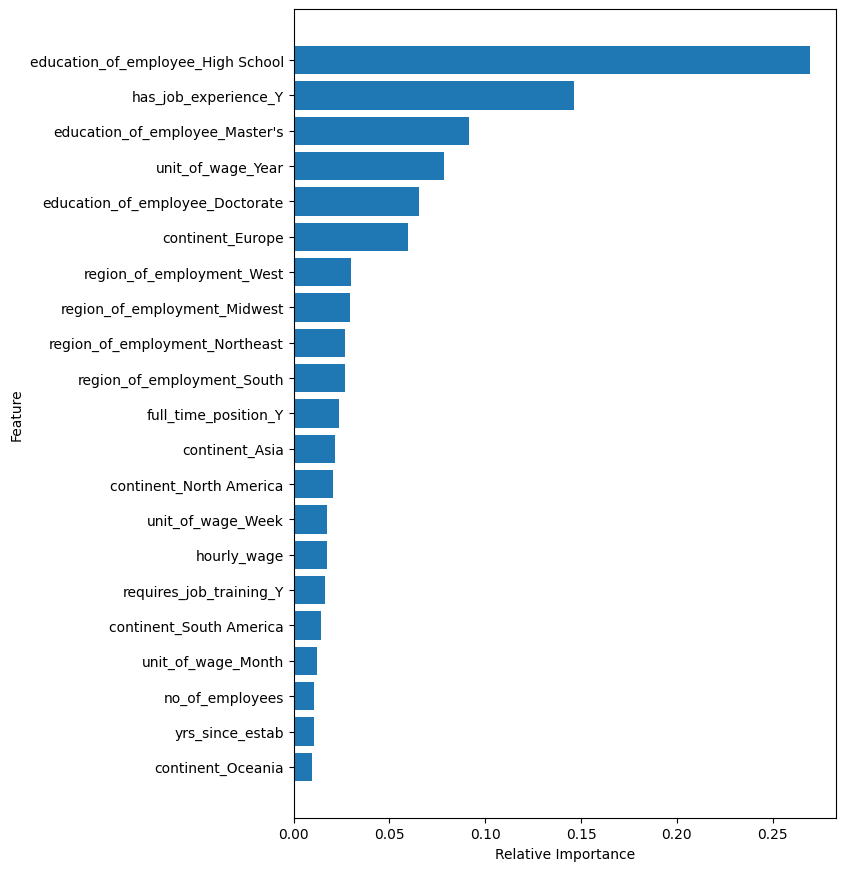

In [ ]:
# checking importances of various features of XGboost gradient boosting cla ssifier
importances =tuning_xg_boost.feature_importances_
column_names =list(X.columns)
indices =np.argsort(importances)
plt.figure(figsize=(7, 0.5*len(column_names)))
plt.barh(range(len(indices)), importances[indices], align="center")
plt.yticks(range(len(indices)), [column_names[i] for i in indices])
plt.xlabel("Relative Importance", fontsize=10)
plt.ylabel("Feature", fontsize=10)
plt.show()

**Observations:**

* Top three independent features of importance in the tuned XGBoost model are education_of_employee_high_school, has_job_experience_Y and education_of_employee_Master's.

### **Stacking Classifier**

In [ ]:
# using function XGBClassifier from sklearn to build model
stacking =StackingClassifier(
    estimators=[
        ("Decision Tree", tuning_decision_tree),
         ("Random Forest",tuning_decision_tree ),
          ("AdaBoost",tuning_decision_tree),
           ("Gradient Boosting", tuning_decision_tree), ],
    final_estimator=tuning_xg_boost, )
stacking.fit(X_train, y_train)

StackingClassifier(estimators=[('Decision Tree',
                                DecisionTreeClassifier(max_depth=np.int64(4),
                                                       max_leaf_nodes=np.int64(14),
                                                       min_impurity_decrease=0.0001,
                                                       min_samples_split=50,
                                                       random_state=1)),
                               ('Random Forest',
                                DecisionTreeClassifier(max_depth=np.int64(4),
                                                       max_leaf_nodes=np.int64(14),
                                                       min_impurity_decrease=0.0001,
                                                       min_samples_split=50,
                                                       random_state=1)),
                               ('AdaBo...
                                                 feature_weights=None, gamma=3,
                                                 grow_policy=None,
                                                 importance_type=None,
                                                 interaction_constraints=None,
                                                 learning_rate=0.1,
                                                 max_bin=None,
                                                 max_cat_threshold=None,
                                                 max_cat_to_onehot=None,
                                                 max_delta_step=None,
                                                 max_depth=None,
                                                 max_leaves=None,
                                                 min_child_weight=None,
                                                 missing=nan,
                                                 monotone_constraints=None,
                                                 multi_strategy=None,
                                                 n_estimators=50, n_jobs=None,
                                                 num_parallel_tree=None, ...))

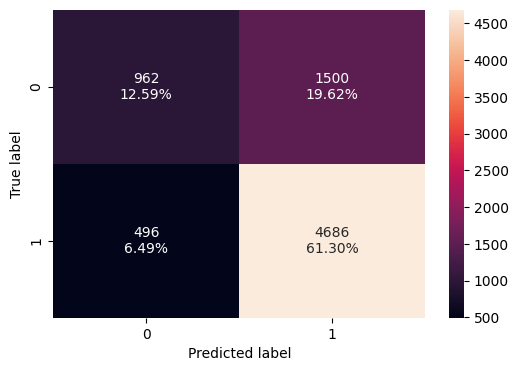

In [ ]:
#create a confusion matrix of the classifier's performance on the testing data
confusion_matrix_sklearn(stacking, X_test,y_test)

In [ ]:
staking_model_train_perf = model_performance_classification_sklearn(stacking,X_train,y_train)
print("Training performance \n",xgb_classifier_model_train_perf)

Training performance 
    Accuracy    Recall  Precision       F1
0  0.837295  0.928439   0.842456  0.88336


In [ ]:
staking_model_test_perf = model_performance_classification_sklearn(stacking,X_train,y_train)
print("Training performance \n",xgb_classifier_model_train_perf)

Training performance 
    Accuracy    Recall  Precision       F1
0  0.837295  0.928439   0.842456  0.88336


**Observations:**

* Almost the same performance to the tuned XGBoost in terms of all metrics.

## **Model Performance Comparison and Conclusions On Bagging and Boosting**

### **Base models comparison**

In [ ]:
# create a dataframe comparing the performance of the base models on the training data

models_train_comp_df = pd.concat(
    [dtree_model_train_perf.T,
     bagging_model_train_perf.T,
     rf_model_train_perf.T,
     ab_classifier_model_train_perf.T,
     gbc_classifier_model_train_perf.T,
     xgb_classifier_model_train_perf.T],
    axis=1,
)
models_train_comp_df.columns = [
    "Decision Tree",
    "Bagging Classifier",
    "Random Forest",
    "AdaBoost Classifier",
    "Gradient Boosting Classifier",
    "XGBoost Classifier"]
print("Training performance comparison of base models:")
models_train_comp_df

Training performance comparison of base models:


,Decision Tree,Bagging Classifier,Random Forest,AdaBoost Classifier,Gradient Boosting Classifier,XGBoost Classifier
Accuracy,1.0,0.985311,0.999944,0.738731,0.755326,0.837295
Recall,1.0,0.986397,1.000000,0.877746,0.874789,0.928439
Precision,1.0,0.991423,0.999916,0.763785,0.782261,0.842456
F1,1.0,0.988904,0.999958,0.816809,0.825941,0.883360


In [ ]:
# create a dataframe comparing the performance of the base models on the testing data

models_test_comp_df = pd.concat(
    [dtree_model_test_perf.T,
     bagging_model_test_perf.T,
     rf_model_test_perf.T,
     ab_classifier_model_test_perf.T,
     gbc_classifier_model_test_perf.T,
     xgb_classifier_model_test_perf.T],
    axis=1,
)
models_test_comp_df.columns = [
    "Decision Tree",
    "Bagging Classifier",
    "Random Forest",
    "AdaBoost Classifier",
    "Gradient Boosting Classifier",
    "XGBoost Classifier"]
print("Testing performance comparison of base models:")
models_test_comp_df

Testing performance comparison of base models:


,Decision Tree,Bagging Classifier,Random Forest,AdaBoost Classifier,Gradient Boosting Classifier,XGBoost Classifier
Accuracy,0.659471,0.705913,0.731554,0.743328,0.750262,0.735086
Recall,0.742184,0.782709,0.840409,0.876882,0.866268,0.849093
Precision,0.752200,0.783314,0.780466,0.774369,0.786854,0.779727
F1,0.747159,0.783012,0.809329,0.822443,0.824653,0.812933


### **Tuned models comparison**

In [ ]:
# create a dataframe comparing the performance of the tuned models on the training data

tuned_models_train_comp_df = pd.concat(
    [dtree_estimator_model_train_perf.T,
     bagging_estimator_model_train_perf.T,
     rf_estimator_model_train_perf.T,
     abc_tuned_model_train_perf.T,
     gb_tuned_model_train_perf.T,
     xgb_tuned_model_train_perf.T],
    axis=1,
)
tuned_models_train_comp_df.columns = [
    "Tuned Decision Tree",
    "Tuned Bagging Classifier",
    "Tuned Random Forest",
    "Tuned AdaBoost Classifier",
    "Tuned Gradient Boosting Classifier",
    "Tuned XGBoost Classifier"]
print("Training performance comparison of tuned models:")
tuned_models_train_comp_df

Training performance comparison of tuned models:


,Tuned Decision Tree,Tuned Bagging Classifier,Tuned Random Forest,Tuned AdaBoost Classifier,Tuned Gradient Boosting Classifier,Tuned XGBoost Classifier
Accuracy,0.731778,0.998879,0.729984,0.745907,0.750056,0.758410
Recall,0.907317,1.000000,0.927171,0.872423,0.878422,0.874958
Precision,0.744420,0.998313,0.735129,0.773599,0.774970,0.785438
F1,0.817836,0.999156,0.820057,0.820044,0.823460,0.827785


In [ ]:
# create a dataframe comparing the performance of the tuned models on the testing data

tuned_models_test_comp_df = pd.concat(
    [dtree_estimator_model_test_perf.T,
     bagging_estimator_model_test_perf.T,
     rf_estimator_model_test_perf.T,
     abc_tuned_model_test_perf.T,
     gb_tuned_model_test_perf.T,
     xgb_tuned_model_test_perf.T],
    axis=1,
)
tuned_models_test_comp_df.columns = [
    "Tuned Decision Tree",
    "Tuned Bagging Classifier",
    "Tuned Random Forest",
    "Tuned AdaBoost Classifier",
    "Tuned Gradient Boosting Classifier",
    "Tuned XGBoost Classifier"]
print("Testing performance comparison of tuned models:")
tuned_models_test_comp_df

Testing performance comparison of tuned models:


,Tuned Decision Tree,Tuned Bagging Classifier,Tuned Random Forest,Tuned AdaBoost Classifier,Tuned Gradient Boosting Classifier,Tuned XGBoost Classifier
Accuracy,0.738880,0.731947,0.734040,0.747253,0.750654,0.751701
Recall,0.904284,0.896372,0.924354,0.867426,0.873601,0.865110
Precision,0.757517,0.754426,0.744830,0.783101,0.783489,0.788983
F1,0.824419,0.819296,0.824938,0.823109,0.826095,0.825295


### **Model Performance Comparison**

In [ ]:
# create a dataframe comparing the performance all models on the training data
all_models_train_comp = pd.concat([models_train_comp_df,tuned_models_train_comp_df],axis=1)
all_models_train_comp.T.sort_values('F1',ascending=False)

,Accuracy,Recall,Precision,F1
Decision Tree,1.000000,1.000000,1.000000,1.000000
Random Forest,0.999944,1.000000,0.999916,0.999958
Tuned Bagging Classifier,0.998879,1.000000,0.998313,0.999156
Bagging Classifier,0.985311,0.986397,0.991423,0.988904
XGBoost Classifier,0.837295,0.928439,0.842456,0.883360
Tuned XGBoost Classifier,0.758410,0.874958,0.785438,0.827785
Gradient Boosting Classifier,0.755326,0.874789,0.782261,0.825941
Tuned Gradient Boosting Classifier,0.750056,0.878422,0.774970,0.823460
Tuned Random Forest,0.729984,0.927171,0.735129,0.820057
Tuned AdaBoost Classifier,0.745907,0.872423,0.773599,0.820044


In [ ]:
'The best performing model on the training data is the ' + all_models_train_comp.T.sort_values('F1',ascending=False).index[0]


'The best performing model on the training data is the Decision Tree'

In [ ]:
# create a dataframe comparing the performance of all models on the testing data
all_models_test_comp = pd.concat([models_test_comp_df,tuned_models_test_comp_df],axis=1)
all_models_test_comp.T.sort_values('F1',ascending=False)

,Accuracy,Recall,Precision,F1
Tuned Gradient Boosting Classifier,0.750654,0.873601,0.783489,0.826095
Tuned XGBoost Classifier,0.751701,0.865110,0.788983,0.825295
Tuned Random Forest,0.734040,0.924354,0.744830,0.824938
Gradient Boosting Classifier,0.750262,0.866268,0.786854,0.824653
Tuned Decision Tree,0.738880,0.904284,0.757517,0.824419
Tuned AdaBoost Classifier,0.747253,0.867426,0.783101,0.823109
AdaBoost Classifier,0.743328,0.876882,0.774369,0.822443
Tuned Bagging Classifier,0.731947,0.896372,0.754426,0.819296
XGBoost Classifier,0.735086,0.849093,0.779727,0.812933
Random Forest,0.731554,0.840409,0.780466,0.809329


In [ ]:
'The best performing model on the testing data is the ' + all_models_test_comp.T.sort_values('F1',ascending=False).index[0]


'The best performing model on the testing data is the Tuned Gradient Boosting Classifier'

**Observations:**

* On the training data, the Decision Tree achieved the highest performance (F1 = 1.0), indicating it has perfectly fit the training set. However, this also suggests overfitting, as such perfect scores are rarely sustainable on unseen data.

* On the testing data, the Tuned Gradient Boosting Classifier achieved the best F1 score (≈0.83), making it the most reliable model for generalization to new data.

### **Feature importance of: Tuned Gradient Boosting Classifier**

In [ ]:
"""The importance of features in the tree building
(The importance of a feature is computed as the (normalized) total
reduction of the criterion brought by that feature.)"""

print(pd.DataFrame(tuning_gradient_boost.feature_importances_, columns = ["Imp"],
                   index = X_train.columns).sort_values(by = 'Imp', ascending = False).head(10))

                                        Imp
education_of_employee_High School  0.212819
has_job_experience_Y               0.166730
unit_of_wage_Year                  0.141256
education_of_employee_Master's     0.083348
education_of_employee_Doctorate    0.070560
continent_Europe                   0.063136
continent_North America            0.049956
hourly_wage                        0.035837
region_of_employment_Midwest       0.035455
no_of_employees                    0.023901


In [ ]:
feature_names = X_train.columns

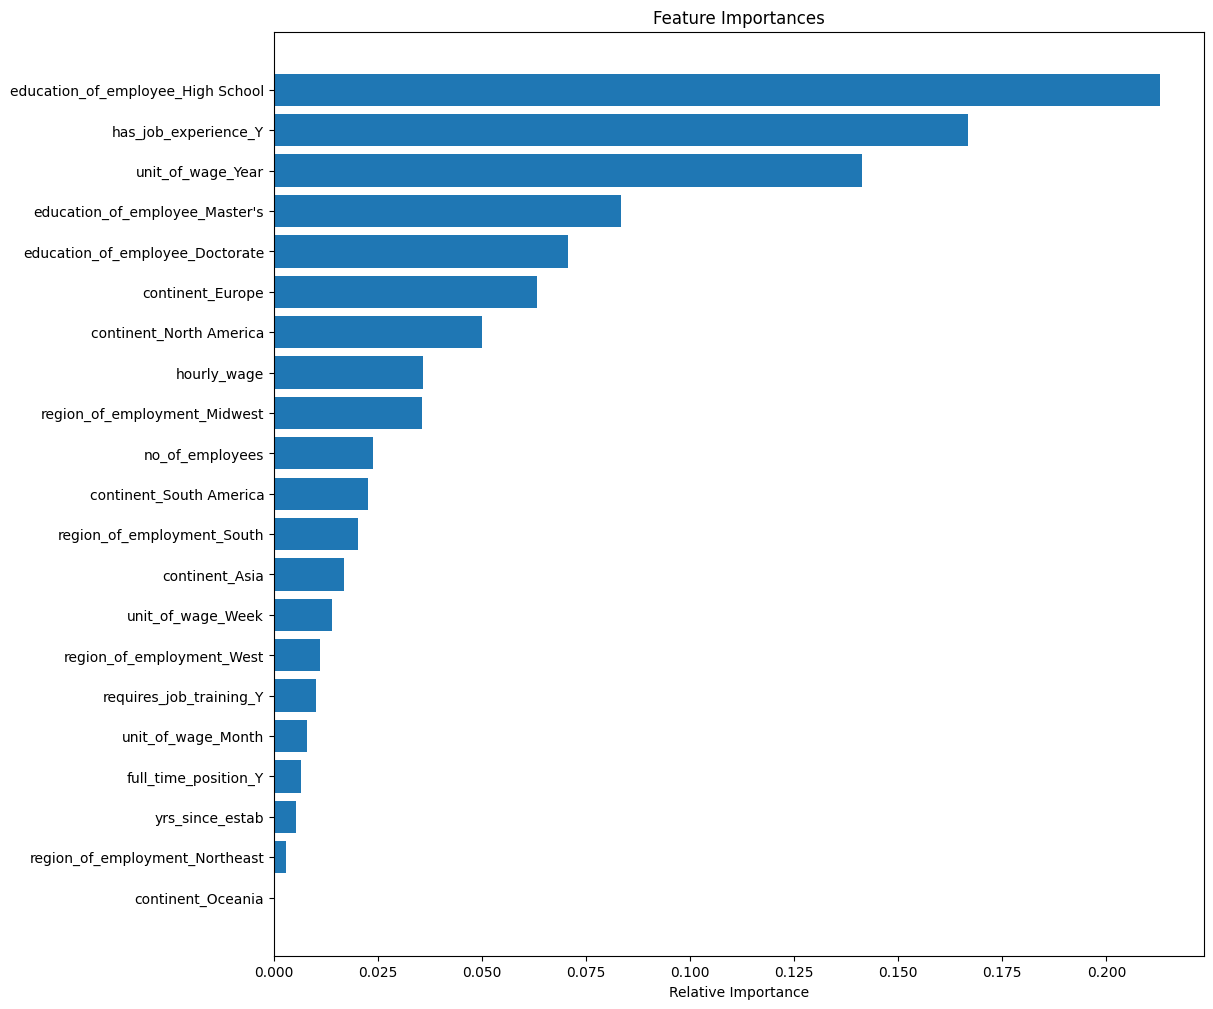

In [ ]:
importances = tuning_gradient_boost.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(12,12))
plt.title('Feature Importances')
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

**Observations:**

The top three independent features of importance in the tuned Gradient model are education_of_employee_high_school, has_job_experience_Y, unit_of_wage_year.

### **Visualization of Decision Tree**

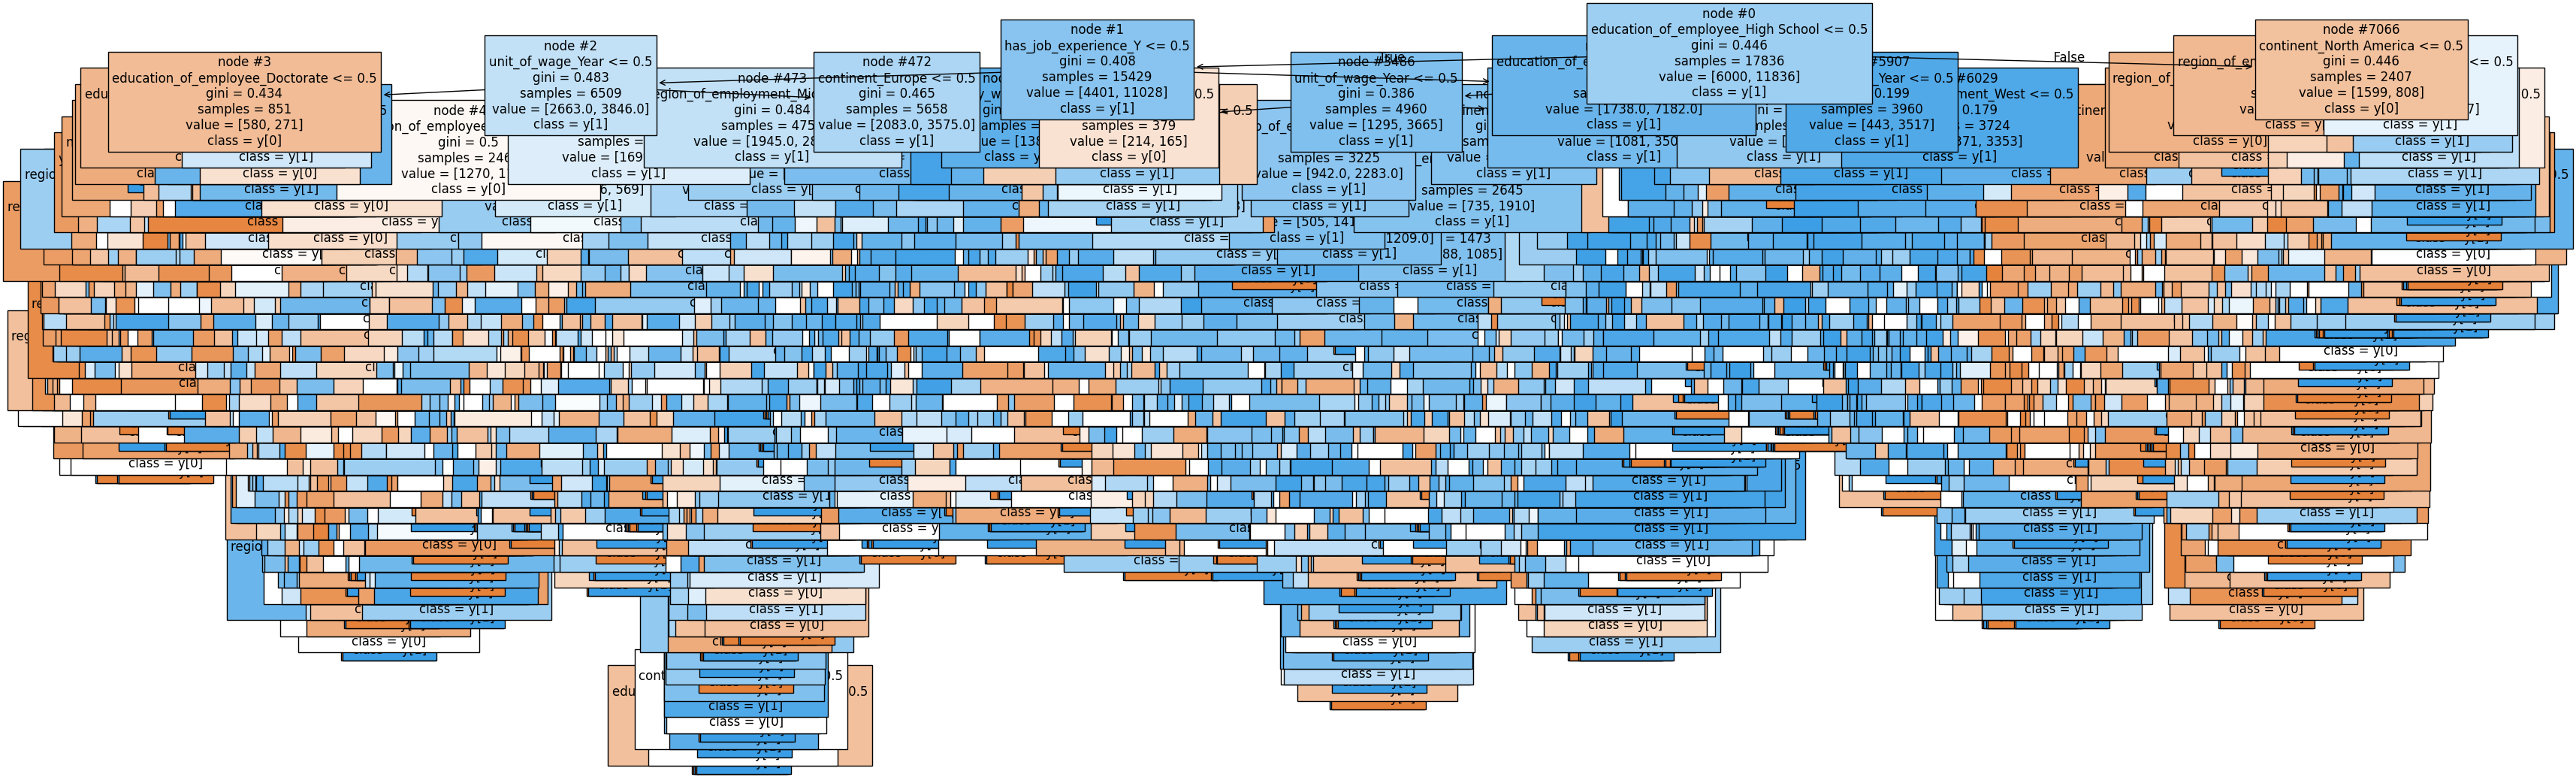

In [ ]:
#creating visualization of tuned decision-tree model
column_names =list(X.columns)
plt.figure(figsize=(40, 12))
tree.plot_tree(decision_tree=dtree,feature_names=column_names,filled=True,fontsize=12,node_ids=True,class_names=True,)
plt.show()

Feature importance of: Decision Tree

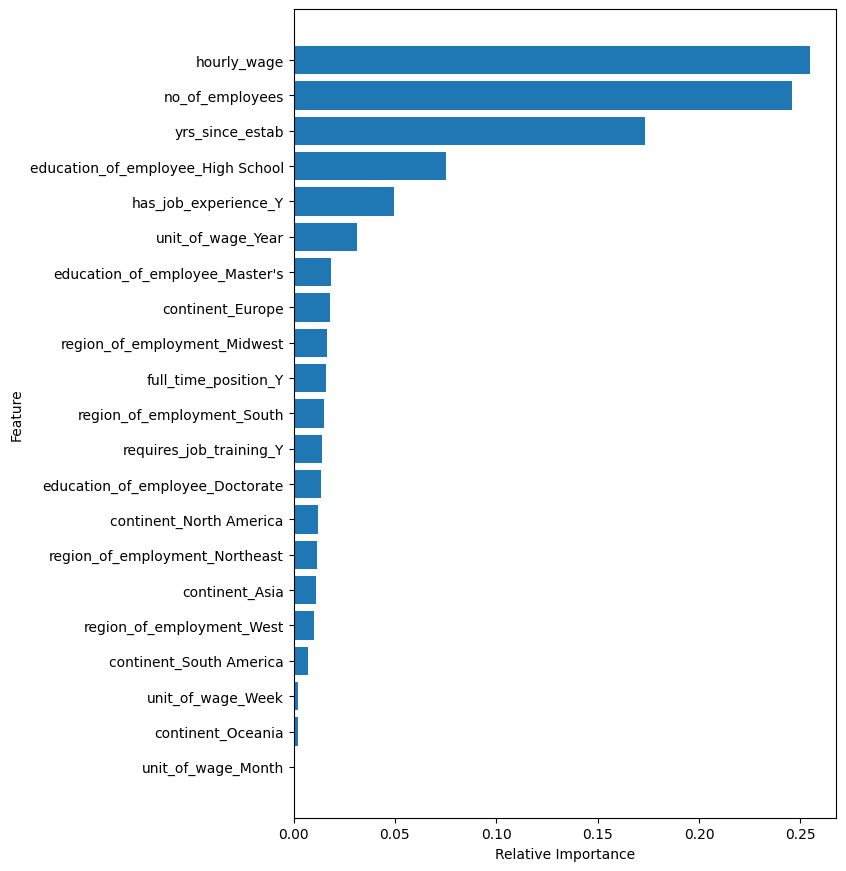

In [ ]:
# checking importances of various features of tuned tree
importances =dtree.feature_importances_
indices =np.argsort(importances)
plt.figure(figsize=(7, 0.5*len(column_names)))
plt.barh(range(len(indices)), importances[indices], align="center")
plt.yticks(range(len(indices)),[column_names[i] for i in indices])
plt.xlabel("Relative Importance", fontsize=10)
plt.ylabel("Feature", fontsize=10)
plt.show()

**Observations:**

The top three independent features of importance in theDecision tree are hourly_wage, no_of_employees, year_since_estab.

## **Model Building For Oversampling and Undersampling**

### **Data Preparation For Modeling**

#### **Splitting the Data**

In [ ]:
# Splitting data into training, validation and test set:
# first we split data into 2 parts, say temporary and test

X_temp, X_test, y_temp, y_test = train_test_split(
    X, Y, test_size=0.2, random_state=1, stratify=Y
)

# then we split the temporary set into train and validation

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=1, stratify=y_temp
)
print(X_train.shape, X_val.shape, X_test.shape)

(15288, 21) (5096, 21) (5096, 21)


In [ ]:
print("Number of rows in train data =", X_train.shape[0])
print("Number of rows in validation data =", X_val.shape[0])
print("Number of rows in test data =", X_test.shape[0])

Number of rows in train data = 15288
Number of rows in validation data = 5096
Number of rows in test data = 5096


### **Model Building**

#### **Model evaluation criterion**

**Model can make wrong predictions as:**
1. Predicting an enrollee is looking for a job change but in reality, the enrollee is not looking for a change - Loss of resources
2. Predicting an enrollee is not looking for a job change but the enrollee is looking for a job change  - Loss of opportunity

**Which case is more important?**
* Predicting an enrollee is not looking for a job change but the enrollee is looking for a job change i.e. losing on a potential candidate as the candidate will not be targeted by the HR team when he should be targeted.

**How to reduce this loss i.e need to reduce False Negatives?**
* Company would want Recall to be maximized, greater the Recall lesser the chances of false negatives.

In [ ]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn
def model_performance_classification_sklearn(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_perf

In [ ]:
def confusion_matrix_sklearn(model, predictors, target):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    y_pred = model.predict(predictors)
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

#### **Model Building - Original Data**

In [ ]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Bagging", BaggingClassifier(estimator=DecisionTreeClassifier(random_state=1, class_weight='balanced'), random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1, class_weight='balanced')))
models.append(("GBM", GradientBoostingClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models.append(("dtree", DecisionTreeClassifier(random_state=1, class_weight='balanced')))

print("\nTraining Performance:\n")
for name, model in models:
    model.fit(X_train, y_train)
    scores = recall_score(y_train, model.predict(X_train))
    print("{}: {}".format(name, scores))

print("\nValidation Performance:\n")
for name, model in models:
    model.fit(X_train, y_train)
    scores_val = recall_score(y_val, model.predict(X_val))
    print("{}: {}".format(name, scores_val))


Training Performance:

Bagging: 0.9885406464250734
Random forest: 1.0
GBM: 0.8774730656219393
Adaboost: 0.8877571008814887
dtree: 1.0

Validation Performance:

Bagging: 0.786427732079906
Random forest: 0.8381316098707403
GBM: 0.8692714453584018
Adaboost: 0.8816098707403055
dtree: 0.7420681551116334


In [ ]:
print("\nTraining and Validation Performance Difference:\n")

for name, model in models:
    model.fit(X_train, y_train)
    scores_train = recall_score(y_train, model.predict(X_train))
    scores_val = recall_score(y_val, model.predict(X_val))
    difference1 = scores_train - scores_val
    print("{}: Training Score: {:.4f}, Validation Score: {:.4f}, Difference: {:.4f}".format(name, scores_train, scores_val, difference1))


Training and Validation Performance Difference:

Bagging: Training Score: 0.9885, Validation Score: 0.7864, Difference: 0.2021
Random forest: Training Score: 1.0000, Validation Score: 0.8381, Difference: 0.1619
GBM: Training Score: 0.8775, Validation Score: 0.8693, Difference: 0.0082
Adaboost: Training Score: 0.8878, Validation Score: 0.8816, Difference: 0.0061
dtree: Training Score: 1.0000, Validation Score: 0.7421, Difference: 0.2579


**Observation:**

Based on the validation performance scores, the AdaBoost model has the highest recall score of approximately 0.8816, followed closely by the GBM model with a recall score of approximately 0.8693.

#### **Model Building - Oversampled Data**

In [ ]:
print("Before Oversampling, counts of label 'Yes': {}".format(sum(y_train == 1)))
print("Before Oversampling, counts of label 'No': {} \n".format(sum(y_train == 0)))

sm = SMOTE(
    sampling_strategy=1, k_neighbors=5, random_state=1
)  # Synthetic Minority Over Sampling Technique
X_train_over, y_train_over = sm.fit_resample(X_train, y_train)


print("After Oversampling, counts of label 'Yes': {}".format(sum(y_train_over == 1)))
print("After Oversampling, counts of label 'No': {} \n".format(sum(y_train_over == 0)))


print("After Oversampling, the shape of train_X: {}".format(X_train_over.shape))
print("After Oversampling, the shape of train_y: {} \n".format(y_train_over.shape))

Before Oversampling, counts of label 'Yes': 10210
Before Oversampling, counts of label 'No': 5078 

After Oversampling, counts of label 'Yes': 10210
After Oversampling, counts of label 'No': 10210 

After Oversampling, the shape of train_X: (20420, 21)
After Oversampling, the shape of train_y: (20420,) 



Model Performance After Oversampling

In [ ]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Bagging", BaggingClassifier(estimator=DecisionTreeClassifier(random_state=1, class_weight='balanced'), random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1, class_weight='balanced')))
models.append(("GBM", GradientBoostingClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models.append(("dtree", DecisionTreeClassifier(random_state=1, class_weight='balanced')))

print("\n" "Training Performance:" "\n")
for name, model in models:
    model.fit(X_train_over, y_train_over)
    scores = recall_score(y_train_over, model.predict(X_train_over))
    print("{}: {}".format(name, scores))

print("\n" "Validation Performance:" "\n")

for name, model in models:
    model.fit(X_train_over, y_train_over)
    scores = recall_score(y_val, model.predict(X_val))
    print("{}: {}".format(name, scores))


Training Performance:

Bagging: 0.9828599412340843
Random forest: 0.9999020568070519
GBM: 0.8489715964740451
Adaboost: 0.8501469147894222
dtree: 1.0

Validation Performance:

Bagging: 0.745005875440658
Random forest: 0.8055229142185664
GBM: 0.8407755581668626
Adaboost: 0.8437132784958872
dtree: 0.7024089306698003


In [ ]:
print("\nTraining and Validation Performance Difference:\n")

for name, model in models:
    model.fit(X_train_over, y_train_over)
    scores_train = recall_score(y_train_over, model.predict(X_train_over))
    scores_val = recall_score(y_val, model.predict(X_val))
    difference2 = scores_train - scores_val
    print("{}: Training Score: {:.4f}, Validation Score: {:.4f}, Difference: {:.4f}".format(name, scores_train, scores_val, difference2))


Training and Validation Performance Difference:

Bagging: Training Score: 0.9829, Validation Score: 0.7450, Difference: 0.2379
Random forest: Training Score: 0.9999, Validation Score: 0.8055, Difference: 0.1944
GBM: Training Score: 0.8490, Validation Score: 0.8408, Difference: 0.0082
Adaboost: Training Score: 0.8501, Validation Score: 0.8437, Difference: 0.0064
dtree: Training Score: 1.0000, Validation Score: 0.7024, Difference: 0.2976


**Observations:**

Based on the validation performance scores after oversampling, the AdaBoost model still has the highest recall score of approximately 0.85, followed closely by the GBM model with a recall score of approximately 0.8408.

#### **Model Building - Undersampled Data**

In [ ]:
rus = RandomUnderSampler(random_state=1)
X_train_un, y_train_un = rus.fit_resample(X_train, y_train)

In [ ]:
print("Before Under Sampling, counts of label 'Yes': {}".format(sum(y_train == 1)))
print("Before Under Sampling, counts of label 'No': {} \n".format(sum(y_train == 0)))

print("After Under Sampling, counts of label 'Yes': {}".format(sum(y_train_un == 1)))
print("After Under Sampling, counts of label 'No': {} \n".format(sum(y_train_un == 0)))

print("After Under Sampling, the shape of train_X: {}".format(X_train_un.shape))
print("After Under Sampling, the shape of train_y: {} \n".format(y_train_un.shape))

Before Under Sampling, counts of label 'Yes': 10210
Before Under Sampling, counts of label 'No': 5078 

After Under Sampling, counts of label 'Yes': 5078
After Under Sampling, counts of label 'No': 5078 

After Under Sampling, the shape of train_X: (10156, 21)
After Under Sampling, the shape of train_y: (10156,) 



Model Performance After Undersampling Data

In [ ]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Bagging", BaggingClassifier(estimator=DecisionTreeClassifier(random_state=1, class_weight='balanced'), random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1, class_weight='balanced')))
models.append(("GBM", GradientBoostingClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models.append(("dtree", DecisionTreeClassifier(random_state=1, class_weight='balanced')))


print("\n" "Training Performance:" "\n")
for name, model in models:
    model.fit(X_train_un, y_train_un)
    scores = recall_score(y_train_un, model.predict(X_train_un))
    print("{}: {}".format(name, scores))

print("\n" "Validation Performance:" "\n")

for name, model in models:
    model.fit(X_train_un, y_train_un)
    scores = recall_score(y_val, model.predict(X_val))
    print("{}: {}".format(name, scores))


Training Performance:

Bagging: 0.9696730996455297
Random forest: 1.0
GBM: 0.7491138243402915
Adaboost: 0.7142575817250886
dtree: 1.0

Validation Performance:

Bagging: 0.6025264394829613
Random forest: 0.6745005875440658
GBM: 0.731198589894242
Adaboost: 0.7079905992949471
dtree: 0.627497062279671


In [ ]:
print("\nTraining and Validation Performance Difference:\n")

for name, model in models:
    model.fit(X_train_un, y_train_un)
    scores_train = recall_score(y_train_un, model.predict(X_train_un))
    scores_val = recall_score(y_val, model.predict(X_val))
    difference3 = scores_train - scores_val
    print("{}: Training Score: {:.4f}, Validation Score: {:.4f}, Difference: {:.4f}".format(name, scores_train, scores_val, difference3))


Training and Validation Performance Difference:

Bagging: Training Score: 0.9697, Validation Score: 0.6025, Difference: 0.3671
Random forest: Training Score: 1.0000, Validation Score: 0.6745, Difference: 0.3255
GBM: Training Score: 0.7491, Validation Score: 0.7312, Difference: 0.0179
Adaboost: Training Score: 0.7143, Validation Score: 0.7080, Difference: 0.0063
dtree: Training Score: 1.0000, Validation Score: 0.6275, Difference: 0.3725


**Observations:**

Based on the validation performance scores after undersampling, the GBM model has the highest recall score of approximately 0.7312, followed by the AdaBoost model with a recall score of approximately 0.7080.

**Observations:**

* It was observed that both the GBM and Adaboost models, trained on an undersampled dataset, as well as the GBM model and Adaboost model trained on an oversampled dataset, exhibited strong performance on both the training and validation datasets.
- Sometimes models might overfit after undersampling and oversampling, so it's better to tune the models to get a generalized performance
- We will tune these models using the same data (undersampled or oversampled) as we trained them on before



### **Hyperparameter Tuning**

#### **Tuning AdaBoostClassifier model with Undersampled data**

In [ ]:
%%time

# defining model
Model = AdaBoostClassifier(random_state=1)

# Parameter grid to pass in RandomSearchCV
param_grid = {
    "n_estimators": np.arange(10, 40, 10),
    "learning_rate": [0.1, 0.01, 0.2, 0.05, 1],
    "estimator": [
        DecisionTreeClassifier(max_depth=1, random_state=1),
        DecisionTreeClassifier(max_depth=2, random_state=1),
        DecisionTreeClassifier(max_depth=3, random_state=1),
    ],
}

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.recall_score)

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid, n_jobs = -1, n_iter=50, scoring=scorer, cv=5, random_state=1)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train_un, y_train_un)

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'n_estimators': np.int64(10), 'learning_rate': 0.1, 'estimator': DecisionTreeClassifier(max_depth=1, random_state=1)} with CV score=0.9312726426438074:
CPU times: user 1.18 s, sys: 94.8 ms, total: 1.28 s
Wall time: 51.5 s


In [ ]:
tuned_adb = AdaBoostClassifier(
    random_state=1,
    n_estimators=20,
    learning_rate=0.1,
    estimator=DecisionTreeClassifier(max_depth=2, random_state=1),
)
tuned_adb.fit(X_train_un, y_train_un)

AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=2,
                                                    random_state=1),
                   learning_rate=0.1, n_estimators=20, random_state=1)

In [ ]:
# Checking model's performance on training set
adb_train = model_performance_classification_sklearn(tuned_adb, X_train_un, y_train_un)
adb_train

,Accuracy,Recall,Precision,F1
0,0.686983,0.655179,0.699685,0.676701


In [ ]:
# Checking model's performance on validation set
adb_val = model_performance_classification_sklearn(tuned_adb, X_val, y_val)
adb_val

,Accuracy,Recall,Precision,F1
0,0.684655,0.660106,0.833148,0.736601


#### **Tuning AdaBoostClassifier model with Oversampled data**

In [ ]:
%%time

# defining model
Model = AdaBoostClassifier(random_state=1)

# Parameter grid to pass in RandomSearchCV
param_grid = {
    "n_estimators": np.arange(10, 40, 10),
    "learning_rate": [0.1, 0.01, 0.2, 0.05, 1],
    "estimator": [
        DecisionTreeClassifier(max_depth=1, random_state=1),
        DecisionTreeClassifier(max_depth=2, random_state=1),
        DecisionTreeClassifier(max_depth=3, random_state=1),
    ],
}

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.recall_score)

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid, n_jobs = -1, n_iter=50, scoring=scorer, cv=5, random_state=1)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train_over, y_train_over)

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'n_estimators': np.int64(10), 'learning_rate': 0.1, 'estimator': DecisionTreeClassifier(max_depth=1, random_state=1)} with CV score=0.9313418217433889:
CPU times: user 1.11 s, sys: 174 ms, total: 1.29 s
Wall time: 1min 29s


In [ ]:
tuned_adb1 = AdaBoostClassifier(
    random_state=1,
    n_estimators=20,
    learning_rate=0.1,
    estimator=DecisionTreeClassifier(max_depth=2, random_state=1),
)
tuned_adb1.fit(X_train_over, y_train_over)

AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=2,
                                                    random_state=1),
                   learning_rate=0.1, n_estimators=20, random_state=1)

In [ ]:
# Checking model's performance on training set
adb_train1 = model_performance_classification_sklearn(tuned_adb1, X_train_over, y_train_over)
adb_train1

,Accuracy,Recall,Precision,F1
0,0.694613,0.904114,0.637148,0.74751


In [ ]:
# Checking model's performance on validation set
adb_val1 = model_performance_classification_sklearn(tuned_adb1, X_val, y_val)
adb_val1

,Accuracy,Recall,Precision,F1
0,0.729788,0.905112,0.745103,0.81735


#### **Tuning  Gradient Boosting model with Undersampled Data**

In [ ]:
%%time

#Creating pipeline
Model = GradientBoostingClassifier(random_state=1)

#Parameter grid to pass in RandomSearchCV
param_grid = {
    "init": [AdaBoostClassifier(random_state=1),DecisionTreeClassifier(random_state=1)],
    "n_estimators": np.arange(125,175,25),
    "learning_rate": [0.01, 0.2, 0.05, 1],
    "subsample":[0.8,0.9,1],
    "max_features":[0.5,0.7,1],
}

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.recall_score)

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid, n_iter=50, scoring=scorer, cv=5, random_state=1, n_jobs = -1)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train_un,y_train_un)

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'subsample': 0.9, 'n_estimators': np.int64(150), 'max_features': 0.5, 'learning_rate': 0.01, 'init': AdaBoostClassifier(random_state=1)} with CV score=0.7426182072068578:
CPU times: user 3.9 s, sys: 277 ms, total: 4.18 s
Wall time: 4min 22s


In [ ]:
tuned_gbm1 = GradientBoostingClassifier(
    random_state=1,
    subsample=0.9,
    n_estimators=150,
    max_features=0.5,
    learning_rate=0.01,
    init=AdaBoostClassifier(random_state=1),
)
tuned_gbm1.fit(X_train_un, y_train_un)

GradientBoostingClassifier(init=AdaBoostClassifier(random_state=1),
                           learning_rate=0.01, max_features=0.5,
                           n_estimators=150, random_state=1, subsample=0.9)

In [ ]:
# Checking model's performance on training set
gbm1_train = model_performance_classification_sklearn(
    tuned_gbm1, X_train_un, y_train_un
)
gbm1_train

,Accuracy,Recall,Precision,F1
0,0.705199,0.743009,0.690773,0.715939


In [ ]:
# Checking model's performance on validation set
gbm1_val = model_performance_classification_sklearn(tuned_gbm1, X_val, y_val)
gbm1_val

,Accuracy,Recall,Precision,F1
0,0.71978,0.73913,0.823298,0.778947


#### **Tuning Gradient Boosting model with Oversampled data**

In [ ]:
%%time

#defining model
Model = GradientBoostingClassifier(random_state=1)

#Parameter grid to pass in RandomSearchCV
param_grid = {
    "init": [AdaBoostClassifier(random_state=1),DecisionTreeClassifier(random_state=1)],
    "n_estimators": np.arange(75,150,25),
    "learning_rate": [0.1, 0.01, 0.2, 0.05, 1],
    "subsample":[0.5,0.7,1],
    "max_features":[0.5,0.7,1],
}

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.recall_score)

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid, n_iter=50, scoring=scorer, cv=5, random_state=1, n_jobs = -1)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train_over, y_train_over)

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'subsample': 0.5, 'n_estimators': np.int64(100), 'max_features': 0.7, 'learning_rate': 0.01, 'init': AdaBoostClassifier(random_state=1)} with CV score=0.8777668952007834:
CPU times: user 4.24 s, sys: 365 ms, total: 4.6 s
Wall time: 5min 38s


In [ ]:
tuned_gbm2 = GradientBoostingClassifier(
    random_state=1,
    subsample=0.7,
    n_estimators=125,
    max_features=1,
    learning_rate=1,
    init=AdaBoostClassifier(random_state=1),
)
tuned_gbm2.fit(X_train_over, y_train_over)

GradientBoostingClassifier(init=AdaBoostClassifier(random_state=1),
                           learning_rate=1, max_features=1, n_estimators=125,
                           random_state=1, subsample=0.7)

In [ ]:
# Checking model's performance on training set
gbm2_train = model_performance_classification_sklearn(tuned_gbm1, X_train_over, y_train_over)
gbm2_train

,Accuracy,Recall,Precision,F1
0,0.68668,0.743879,0.667516,0.703632


In [ ]:
# Checking model's performance on validation set
gbm2_val = model_performance_classification_sklearn(tuned_gbm1, X_val, y_val)
gbm2_val

,Accuracy,Recall,Precision,F1
0,0.71978,0.73913,0.823298,0.778947


## **Model Comparison and Final Model Selection**

In [ ]:
# training performance comparison

models_train_comp_df = pd.concat(
    [
        gbm1_train.T,
        gbm2_train.T,
        adb_train.T,
        adb_train1.T
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Gradient boosting trained with Undersampled data",
    "Gradient boosting trained with Oversampled data",
    "AdaBoost trained with Undersampled data",
    "AdaBoost trained with Oversampled data",
]
print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Gradient boosting trained with Undersampled data,Gradient boosting trained with Oversampled data,AdaBoost trained with Undersampled data,AdaBoost trained with Oversampled data
Accuracy,0.705199,0.686680,0.686983,0.694613
Recall,0.743009,0.743879,0.655179,0.904114
Precision,0.690773,0.667516,0.699685,0.637148
F1,0.715939,0.703632,0.676701,0.747510


In [ ]:
# Validation performance comparison

models_train_comp_df = pd.concat(
    [ gbm1_val.T, gbm2_val.T, adb_val.T, adb_val1.T], axis=1,
)
models_train_comp_df.columns = [
    "Gradient boosting trained with Undersampled data",
    "Gradient boosting trained with Oversampled data",
    "AdaBoost trained with Undersampled data",
    "AdaBoost  trained with Oversampled data"
]
print("Validation performance comparison:")
models_train_comp_df

Validation performance comparison:


,Gradient boosting trained with Undersampled data,Gradient boosting trained with Oversampled data,AdaBoost trained with Undersampled data,AdaBoost trained with Oversampled data
Accuracy,0.719780,0.719780,0.684655,0.729788
Recall,0.739130,0.739130,0.660106,0.905112
Precision,0.823298,0.823298,0.833148,0.745103
F1,0.778947,0.778947,0.736601,0.817350


**Observations:**
* The AdaBoost model trained with Oversampled data has the highest Recall score of approximately 0.905 and highest f1 score approximately 0.817.






In [ ]:
# Let's check the performance on test set
ada_test = model_performance_classification_sklearn(tuned_adb1, X_test, y_test)
ada_test

,Accuracy,Recall,Precision,F1
0,0.71821,0.900118,0.736538,0.810153


**Observations:**

- The Adaboost model trained on Oversampled data has given ~90% recall on the test set
- This performance is in line with what we achieved with this model on the train and validation sets
- So, this is a generalized model

#### **Feature Importance**

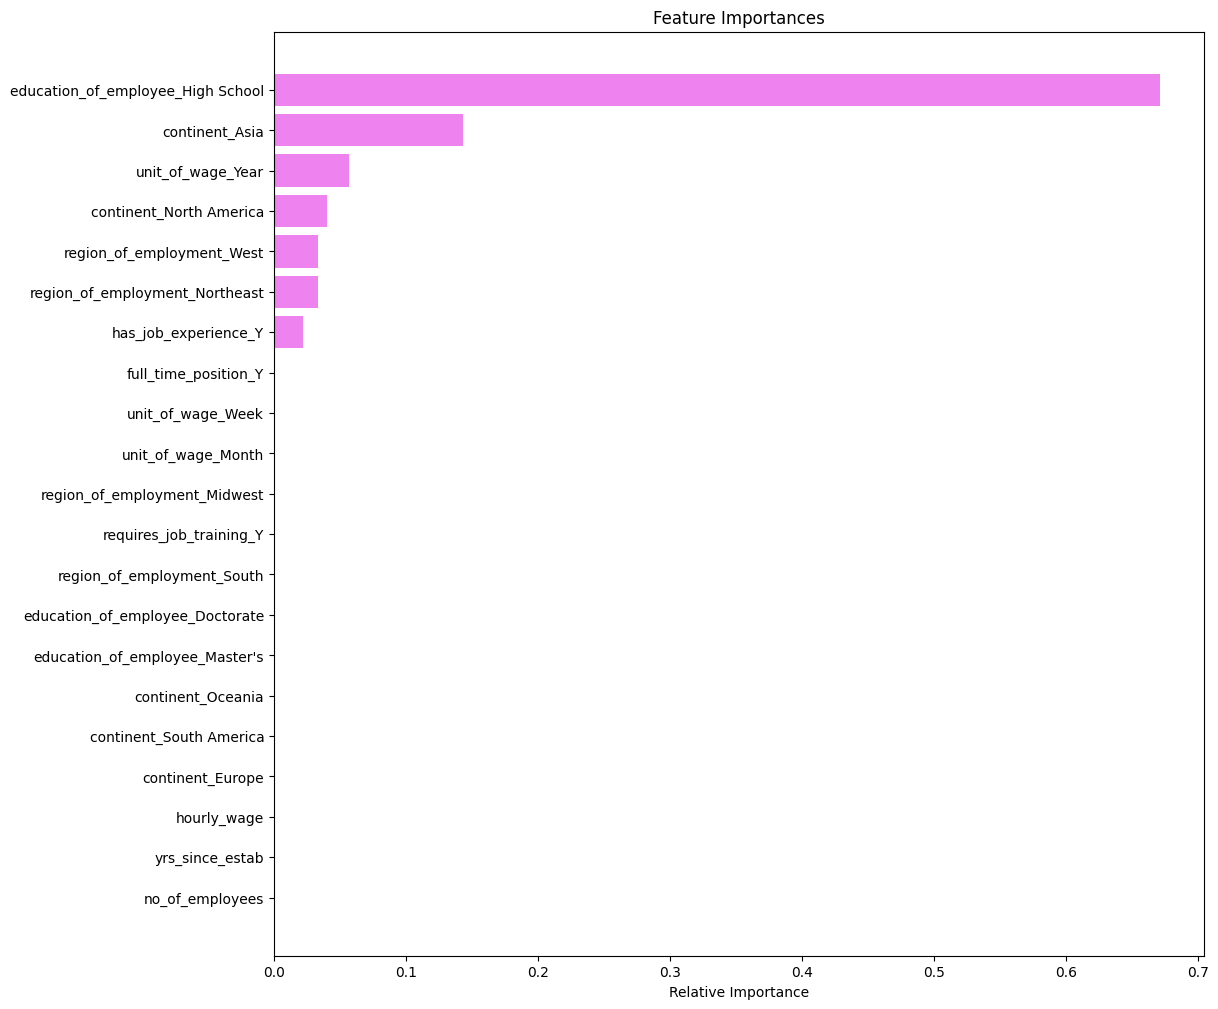

In [ ]:
feature_names = X_train.columns
importances = tuned_adb1.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(12, 12))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

**Observations:**

- We can see that education_of_employee_High School_West, continent_Asia,Unit_of_wage_Year are the most important features for making predictions

## **Actionable Insights and Business Recommendations**

### **Insights**

* Applicants with Master’s and Doctorate degrees are far more likely to get certified compared to those with only high school education.

* Candidates with prior job experience enjoy significantly higher approval rates (~74% vs ~56% for those without).

* Applications offering yearly wages see higher approval chances compared to hourly or weekly wage offers.

* Although Asia has the largest number of applicants, approval rates are higher for applicants from Europe and Africa. Employment in the Midwest and South regions of the U.S. also corresponds with higher approvals.

* Factors like number of employees or establishment year have minimal impact compared to education, experience, and wage type.

* Base Decision Tree models are unreliable – They overfit the training data and fail to generalize on test data.

* Boosting models (AdaBoost, Gradient Boosting, XGBoost) consistently outperform bagging in terms of recall and F1-score.

* Tuned Gradient Boosting Classifier achieved the best balanced performance on the test set (F1 ≈ 0.826, recall ≈ 0.874), making it the most reliable overall model.

* Tuned AdaBoost with oversampling achieved the highest recall (≈0.905), which is very important for minimizing false negatives (not rejecting strong candidates).

### **Recommendations**

* Adopt the Tuned Gradient Boosting Classifier as the primary model, since it provides the best overall balance of recall, precision, and F1-score.

* Use the Tuned AdaBoost model with oversampling in cases where maximizing recall is more critical (ensuring strong applicants are not wrongly rejected).

* Bagging and Random Forest may be used as benchmarking tools but should not be the primary models due to lower recall.

* Apply oversampling techniques (like SMOTE) consistently to handle class imbalance and improve minority (denied) case prediction.

* Hyperparameter tuning should always be performed on ensemble models to reduce overfitting and stabilize performance.

* Develop feature importance, so applicants and advisors understand which factors (education, experience, wages, region) most affect approval chances.

* In the long term, explore stacked ensembles (Gradient Boosting + AdaBoost) for potentially stronger predictive power and robustness.